# Predictive Analytics and Price Optimization for Vehicle Sales

## Using Machine Learning and Business Intelligence

---

### Course Information
**Course**: COMP8811 Data Analytics and Intelligence | **Assignment**: 2 (Individual) | **Semester**: 2, 2025  
**Institution**: Unitec Institute of Technology | **Student**: Sudipta Ghosh (ID: 1606174)

---

### Executive Summary

This project develops a **comprehensive BI solution** for vehicle price prediction, addressing a critical challenge in automotive retail: **optimal pricing to maximize profitability**.

**Problem**: Manual pricing methods are inconsistent, subjective, and fail to adapt quickly to market changes, leading to either overpricing (slow inventory turnover) or underpricing (lost revenue).

**Solution**: ML-powered predictive system using **558,838 real auction records** to forecast selling prices and recommend data-driven pricing strategies.

**Techniques**: Linear Regression (baseline), Random Forest (non-linear patterns), XGBoost (optimal performance)

**Business Value**: Descriptive (market trends) + Predictive (price forecasting) + Prescriptive (strategy optimization)

**Key Metric**: Profit Margin = (Selling Price - MMR Baseline) / MMR × 100%

---

## Table of Contents

1. [Setup](#s1) | 2. [Business Problem](#s2) | 3. [EDA](#s3) | 4. [Preprocessing](#s4)
5. [Linear Regression](#s5) | 6. [Random Forest](#s6) | 7. [XGBoost](#s7)  
8. [Model Comparison](#s8) | 9. [BI Insights](#s9) | 10. [Pricing Strategy](#s10) | 11. [Conclusion](#s11)

---

<a id='s1'></a>
## Section 1: Setup and Environment

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Config
plt.rcParams['figure.dpi'], plt.rcParams['figure.figsize'] = 100, (12, 8)
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
RANDOM_SEED = 74
np.random.seed(RANDOM_SEED)

print("="*80)
print("✓ ENVIRONMENT READY | Seed: 74 | Libraries: NumPy, Pandas, Sklearn, XGBoost")
print("="*80)

✓ ENVIRONMENT READY | Seed: 74 | Libraries: NumPy, Pandas, Sklearn, XGBoost


<a id='s2'></a>
## Section 2: Business Problem & Dataset

### Problem Statement
**Context**: Dealerships struggle with optimal vehicle pricing  
**Impact**: Overpricing → slow sales | Underpricing → lost profit  
**Goal**: ML system for accurate price prediction + strategic recommendations

**Questions**:
1. What's the fair market value for a vehicle?
2. Which features drive price?
3. What markup above MMR baseline is achievable?

**Success**: MAPE < 10%, 5-10% profit improvement

### Dataset
**Size**: 558,838 auction records  
**Features**: year, make, model, body, mileage, condition, mmr (baseline)  
**Target**: sellingprice (USD)  
**Business Metric**: Profit Margin = (sellingprice - mmr) / mmr

---

### 2.1 Load Dataset

In [2]:
start = time.time()
df = pd.read_csv("dataset/car_prices.csv")
print(f"Loaded {len(df):,} records in {time.time()-start:.2f}s")
print(f"  Features: {len(df.columns)} | Memory: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")
df.head()

Loaded 558,837 records in 0.61s
  Features: 16 | Memory: 417.9 MB


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [4]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


<a id='s3'></a>
## Section 3: Exploratory Data Analysis

### 3.1 Data Quality

In [5]:
# Missing values & duplicates
missing = df.isnull().sum()
print("Missing values:", "None" if missing.sum() == 0 else f"\n{missing[missing>0]}")
print(f"Duplicates: {df.duplicated().sum():,} ({df.duplicated().sum()/len(df)*100:.1f}%)")

Missing values: 
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
condition       11820
odometer           94
color             749
interior          749
mmr                38
sellingprice       12
saledate           12
dtype: int64
Duplicates: 0 (0.0%)


### 3.2 Target Variable: Selling Price

SELLING PRICE ANALYSIS
Mean:   $13,611.36
Median: $12,100.00
Range:  $1 - $230,000


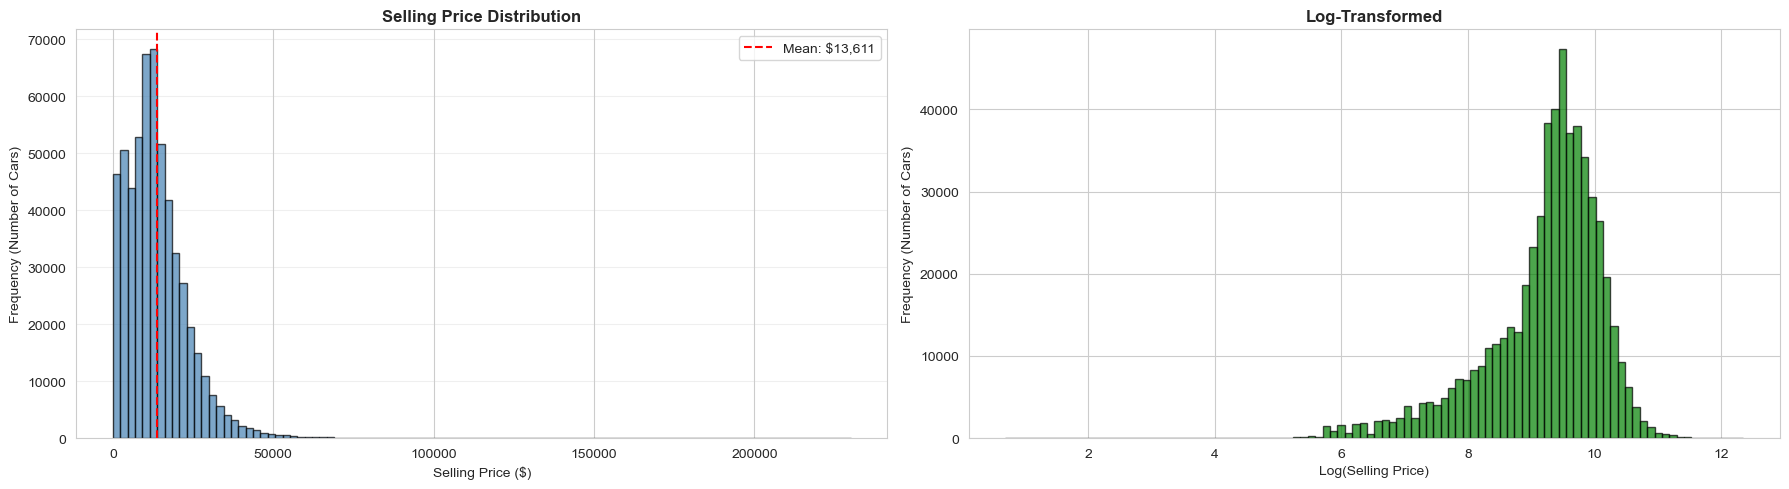

In [6]:
# Price statistics
print("="*60)
print("SELLING PRICE ANALYSIS")
print("="*60)
print(f"Mean:   ${df['sellingprice'].mean():,.2f}")
print(f"Median: ${df['sellingprice'].median():,.2f}")
print(f"Range:  ${df['sellingprice'].min():,.0f} - ${df['sellingprice'].max():,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
# Histogram
axes[0].hist(df['sellingprice'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['sellingprice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["sellingprice"].mean():,.0f}')
axes[0].set_title('Selling Price Distribution', fontweight='bold')
axes[0].set_xlabel('Selling Price ($)')
axes[0].set_ylabel('Frequency (Number of Cars)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)


# Log scale
axes[1].hist(np.log1p(df['sellingprice']), bins=100, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('Log-Transformed', fontweight='bold')
axes[1].set_xlabel('Log(Selling Price)')
axes[1].set_ylabel('Frequency (Number of Cars)')

plt.tight_layout()
plt.show()

### 3.3 Profit Margin Analysis

**Critical Business Metric**: Profit Margin = (Selling Price - MMR) / MMR × 100%

PROFIT MARGIN ANALYSIS
Mean Margin:   -0.66%
Median Margin: -0.42%
Mean Profit:   $-158.02
Total Profit:  $-88,302,088

Sold above MMR: 261,161 (46.7%) ← PROFIT
Sold below MMR: 286,415 ← LOSS


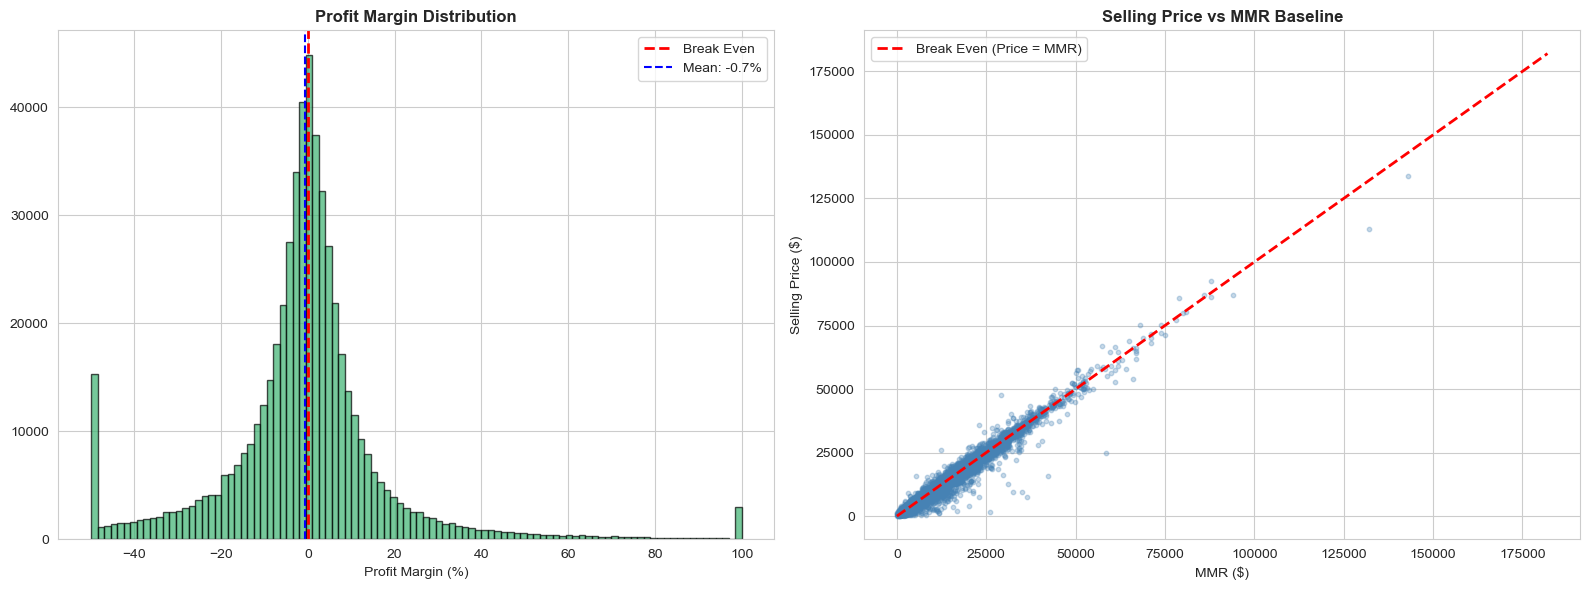

In [7]:
# Calculate profit metrics
df['profit_margin'] = ((df['sellingprice'] - df['mmr']) / df['mmr']) * 100
df['profit_amount'] = df['sellingprice'] - df['mmr']

print("="*60)
print("PROFIT MARGIN ANALYSIS")
print("="*60)
print(f"Mean Margin:   {df['profit_margin'].mean():.2f}%")
print(f"Median Margin: {df['profit_margin'].median():.2f}%")
print(f"Mean Profit:   ${df['profit_amount'].mean():,.2f}")
print(f"Total Profit:  ${df['profit_amount'].sum():,.0f}")

above_mmr = (df['sellingprice'] > df['mmr']).sum()
print(f"\nSold above MMR: {above_mmr:,} ({above_mmr/len(df)*100:.1f}%) ← PROFIT")
print(f"Sold below MMR: {(df['sellingprice'] < df['mmr']).sum():,} ← LOSS")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Margin distribution
axes[0].hist(df['profit_margin'].clip(-50, 100), bins=100, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Break Even')
axes[0].axvline(df['profit_margin'].mean(), color='blue', linestyle='--', label=f'Mean: {df["profit_margin"].mean():.1f}%')
axes[0].set_title('Profit Margin Distribution', fontweight='bold')
axes[0].set_xlabel('Profit Margin (%)')
axes[0].legend()

# MMR vs Selling Price
sample = df.sample(n=min(10000, len(df)), random_state=42)
axes[1].scatter(sample['mmr'], sample['sellingprice'], alpha=0.3, s=10, color='steelblue')
axes[1].plot([df['mmr'].min(), df['mmr'].max()], [df['mmr'].min(), df['mmr'].max()], 
             'r--', linewidth=2, label='Break Even (Price = MMR)')
axes[1].set_title('Selling Price vs MMR Baseline', fontweight='bold')
axes[1].set_xlabel('MMR ($)')
axes[1].set_ylabel('Selling Price ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Vehicle Characteristics

Top 10 Vehicle Makes:
make
Ford         93554
Chevrolet    60197
Nissan       53946
Toyota       39871
Dodge        30710
Honda        27206
Hyundai      21816
BMW          20719
Kia          18077
Chrysler     17276
Name: count, dtype: int64

Average Price by Top 10 Makes:
make
Rolls-Royce     153488.235294
Ferrari         127210.526316
Lamborghini     112625.000000
Bentley          74367.672414
airstream        71000.000000
Tesla            67054.347826
Aston Martin     54812.000000
Fisker           46461.111111
Maserati         45320.300752
Lotus            40800.000000
Name: sellingprice, dtype: float64


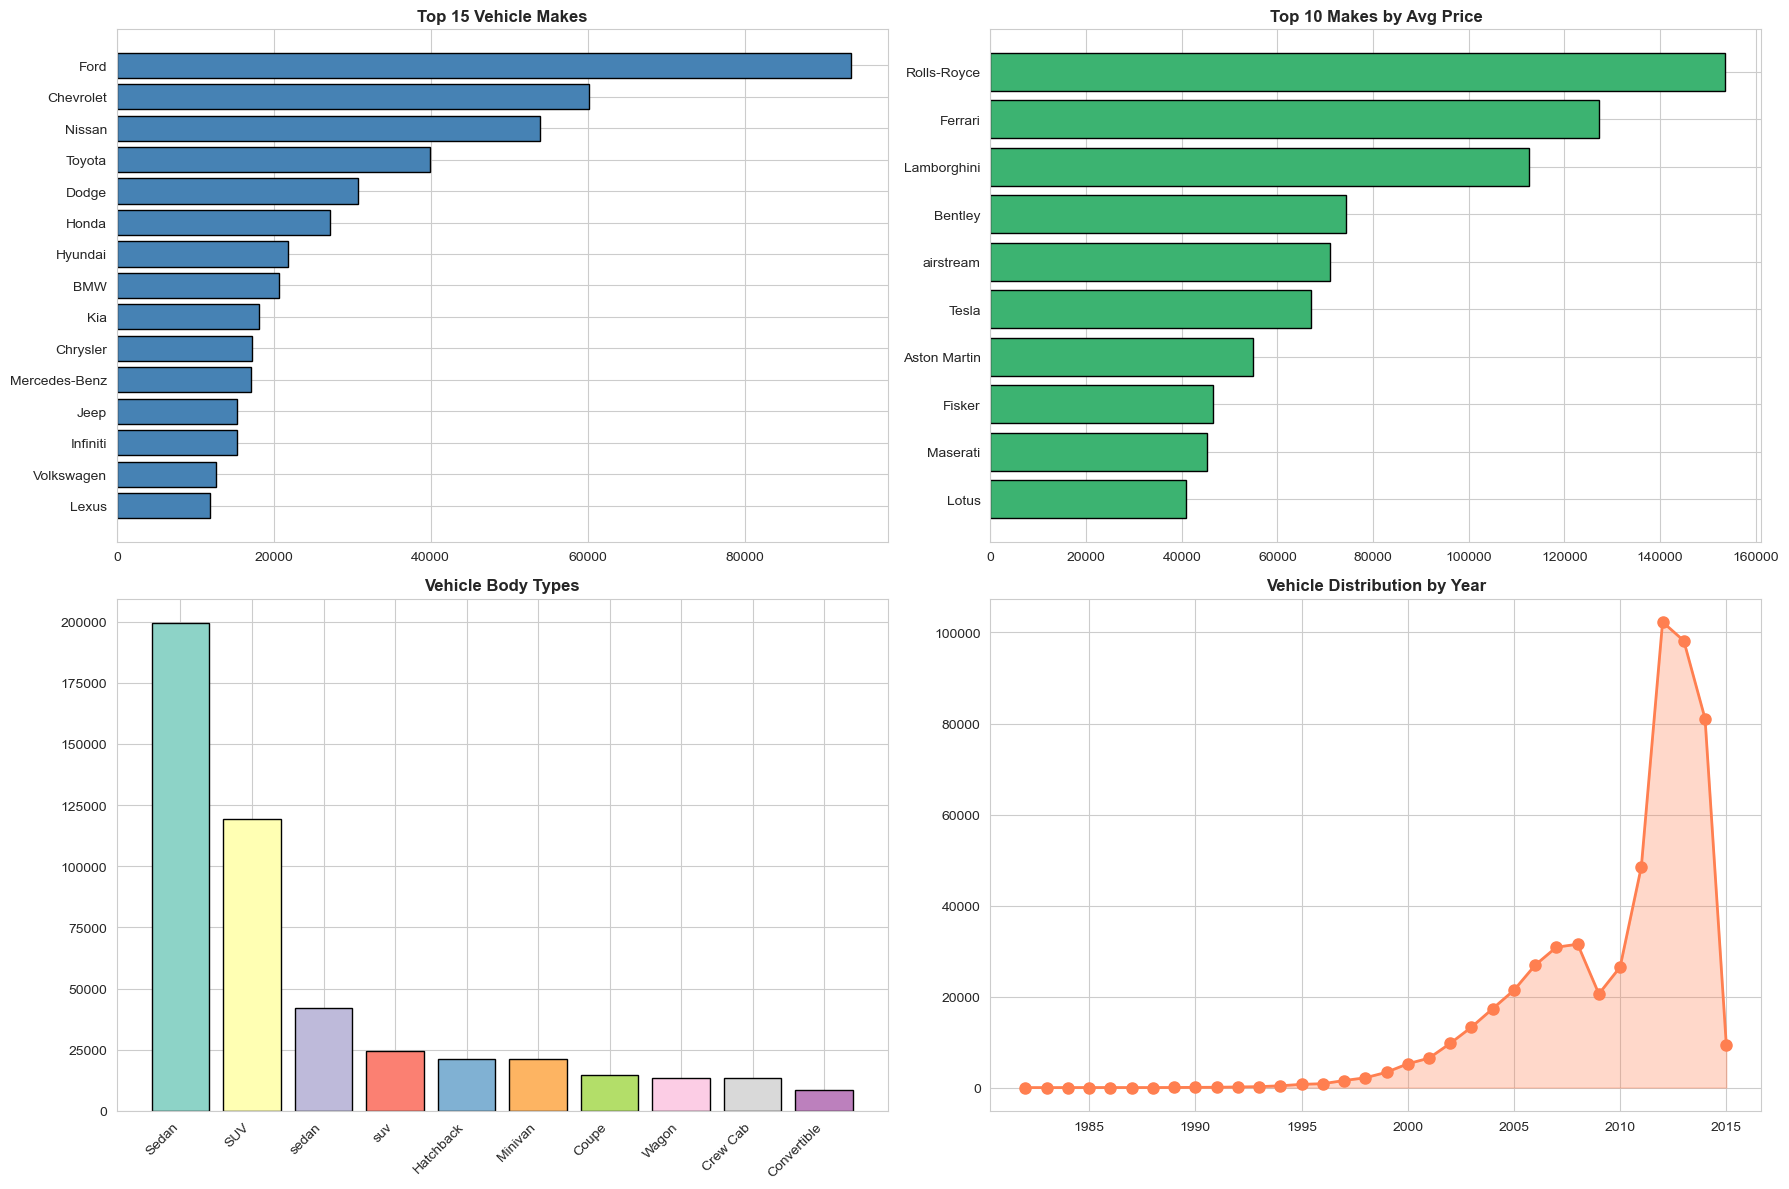

In [8]:
# Top makes
print("Top 10 Vehicle Makes:")
print(df['make'].value_counts().head(10))

print("\nAverage Price by Top 10 Makes:")
print(df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(10))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top makes
top_makes = df['make'].value_counts().head(15)
axes[0, 0].barh(range(len(top_makes)), top_makes.values, color='steelblue', edgecolor='black')
axes[0, 0].set_yticks(range(len(top_makes)))
axes[0, 0].set_yticklabels(top_makes.index)
axes[0, 0].set_title('Top 15 Vehicle Makes', fontweight='bold')
axes[0, 0].invert_yaxis()

# Price by make
top_price_makes = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(10)
axes[0, 1].barh(range(len(top_price_makes)), top_price_makes.values, color='mediumseagreen', edgecolor='black')
axes[0, 1].set_yticks(range(len(top_price_makes)))
axes[0, 1].set_yticklabels(top_price_makes.index)
axes[0, 1].set_title('Top 10 Makes by Avg Price', fontweight='bold')
axes[0, 1].invert_yaxis()

# Body types
body_counts = df['body'].value_counts().head(10)
axes[1, 0].bar(range(len(body_counts)), body_counts.values, color=plt.cm.Set3(range(len(body_counts))), edgecolor='black')
axes[1, 0].set_xticks(range(len(body_counts)))
axes[1, 0].set_xticklabels(body_counts.index, rotation=45, ha='right')
axes[1, 0].set_title('Vehicle Body Types', fontweight='bold')

# Year distribution
year_counts = df['year'].value_counts().sort_index()
axes[1, 1].plot(year_counts.index, year_counts.values, marker='o', linewidth=2, markersize=8, color='coral')
axes[1, 1].fill_between(year_counts.index, year_counts.values, alpha=0.3, color='coral')
axes[1, 1].set_title('Vehicle Distribution by Year', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.5 Feature Correlations

Correlation with Selling Price:
sellingprice    1.000000
mmr             0.983635
year            0.586480
condition       0.321944
odometer       -0.582393
Name: sellingprice, dtype: float64


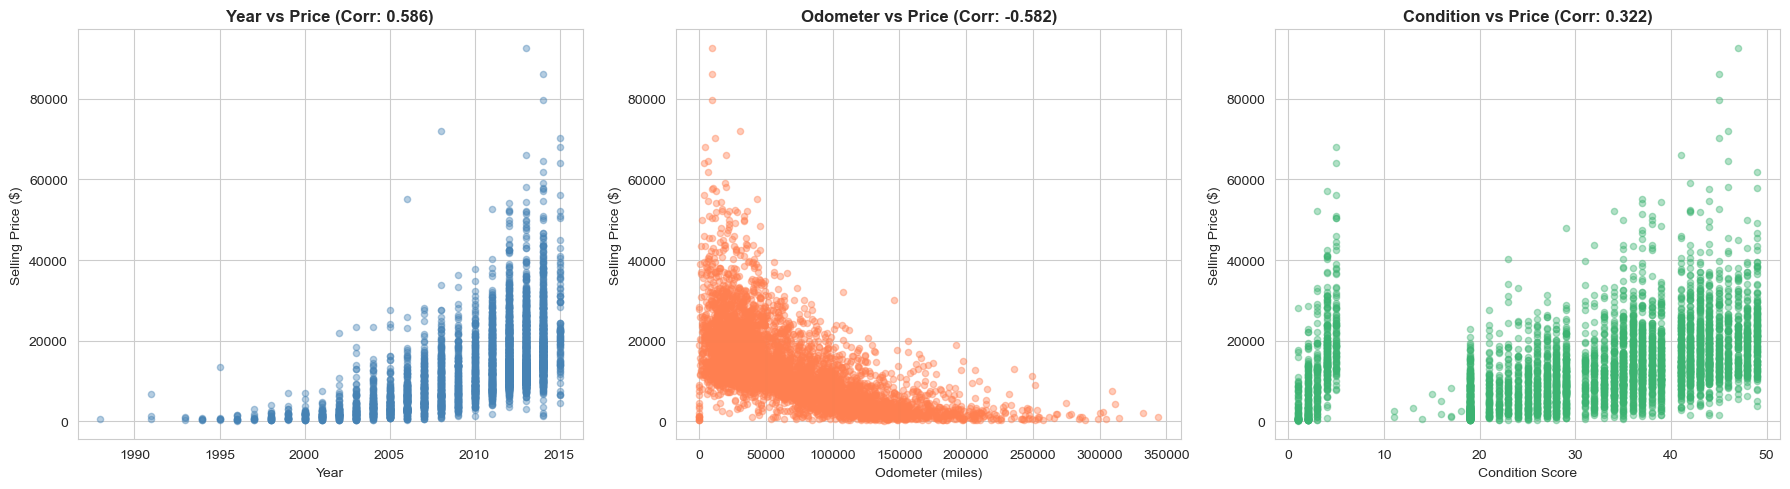

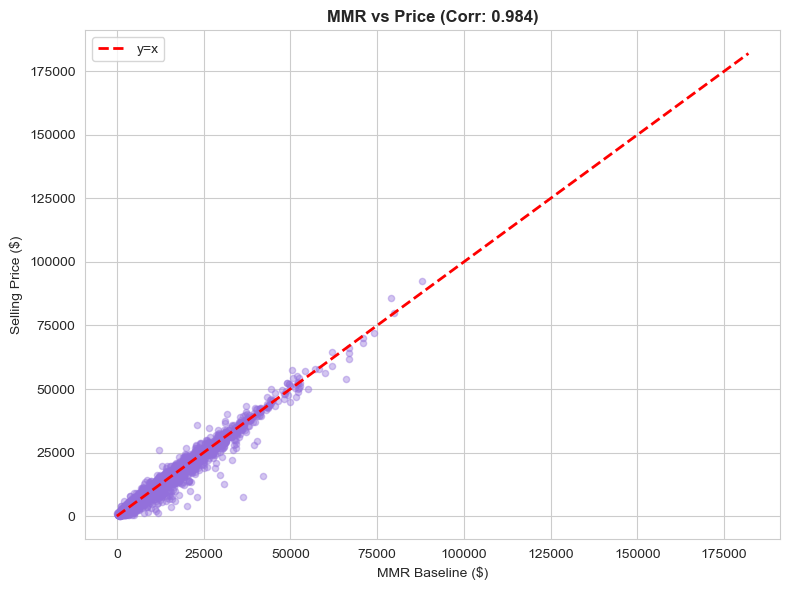


💡 Key Insight: MMR has strongest correlation → it's the primary price driver!


In [9]:
# Correlation analysis
numerical_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
corr = df[numerical_cols].corr()['sellingprice'].sort_values(ascending=False)

print("Correlation with Selling Price:")
print(corr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample = df.sample(n=min(5000, len(df)), random_state=42)

# Year vs Price
axes[0].scatter(sample['year'], sample['sellingprice'], alpha=0.4, s=20, color='steelblue')
axes[0].set_title(f'Year vs Price (Corr: {df["year"].corr(df["sellingprice"]):.3f})', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Selling Price ($)')

# Odometer vs Price
axes[1].scatter(sample['odometer'], sample['sellingprice'], alpha=0.4, s=20, color='coral')
axes[1].set_title(f'Odometer vs Price (Corr: {df["odometer"].corr(df["sellingprice"]):.3f})', fontweight='bold')
axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('Selling Price ($)')

# Condition vs Price
axes[2].scatter(sample['condition'], sample['sellingprice'], alpha=0.4, s=20, color='mediumseagreen')
axes[2].set_title(f'Condition vs Price (Corr: {df["condition"].corr(df["sellingprice"]):.3f})', fontweight='bold')
axes[2].set_xlabel('Condition Score')
axes[2].set_ylabel('Selling Price ($)')

plt.tight_layout()
plt.show()

# MMR vs Price (MOST IMPORTANT!)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(sample['mmr'], sample['sellingprice'], alpha=0.4, s=20, color='mediumpurple')
ax.plot([df['mmr'].min(), df['mmr'].max()], [df['mmr'].min(), df['mmr'].max()], 'r--', linewidth=2, label='y=x')
ax.set_title(f'MMR vs Price (Corr: {df["mmr"].corr(df["sellingprice"]):.3f})', fontweight='bold')
ax.set_xlabel('MMR Baseline ($)')
ax.set_ylabel('Selling Price ($)')
ax.legend()

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: MMR has strongest correlation → it's the primary price driver!")

<a id='s4'></a>
## Section 4: Data Preprocessing & Feature Engineering

### 4.1 Data Cleaning

In [10]:
df_clean = df.copy()
orig_size = len(df_clean)

print("="*60)
print("DATA CLEANING")
print("="*60)
print(f"Original: {orig_size:,} records")

# Remove missing target/MMR
df_clean = df_clean.dropna(subset=['sellingprice', 'mmr'])
print(f"After removing missing price/MMR: {len(df_clean):,}")

# Remove unrealistic prices
df_clean = df_clean[(df_clean['sellingprice'] >= 500) & (df_clean['sellingprice'] <= 500000)]
print(f"After price filter ($500-$500K): {len(df_clean):,}")

# Remove extreme odometer
df_clean = df_clean[df_clean['odometer'] <= 500000]
print(f"After odometer filter (<500K miles): {len(df_clean):,}")

# Fill missing condition with median
if df_clean['condition'].isnull().sum() > 0:
    median_cond = df_clean['condition'].median()
    df_clean['condition'].fillna(median_cond, inplace=True)
    print(f"Filled missing condition with median: {median_cond}")

# Remove missing critical features
critical = ['make', 'model', 'body', 'transmission']
df_clean = df_clean.dropna(subset=critical)
print(f"After removing missing critical features: {len(df_clean):,}")

print(f"\n Removed {orig_size - len(df_clean):,} records ({(orig_size - len(df_clean))/orig_size*100:.2f}%)")
print(f"Final dataset: {len(df_clean):,} records")
print("="*60)

DATA CLEANING
Original: 558,837 records
After removing missing price/MMR: 558,799
After price filter ($500-$500K): 553,462
After odometer filter (<500K miles): 553,319
Filled missing condition with median: 35.0
After removing missing critical features: 478,150

 Removed 80,687 records (14.44%)
Final dataset: 478,150 records


### 4.2 Feature Engineering

Create business-relevant features:

In [11]:
print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Vehicle age (more intuitive than year)
current_year = 2015  # Based on dataset
df_clean['vehicle_age'] = current_year - df_clean['year']
print("✓ vehicle_age = current_year - year")

# Luxury brand indicator
luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Lexus', 'Porsche', 'Jaguar', 
                 'Land Rover', 'Cadillac', 'Tesla', 'Maserati']
df_clean['is_luxury'] = df_clean['make'].isin(luxury_brands).astype(int)
print(f"✓ is_luxury (1 if luxury, 0 otherwise) - {df_clean['is_luxury'].sum():,} luxury vehicles")

# Mileage category
def mileage_cat(miles):
    if miles < 30000: return 'Low'
    elif miles < 60000: return 'Medium'
    elif miles < 100000: return 'High'
    else: return 'Very High'

df_clean['mileage_category'] = df_clean['odometer'].apply(mileage_cat)
print("✓ mileage_category (Low, Medium, High, Very High)")

# Condition category
def condition_cat(score):
    if pd.isna(score): return 'Unknown'
    elif score >= 40: return 'Excellent'
    elif score >= 30: return 'Good'
    elif score >= 20: return 'Fair'
    else: return 'Poor'

df_clean['condition_category'] = df_clean['condition'].apply(condition_cat)
print("✓ condition_category (Excellent, Good, Fair, Poor)")

# Simplified body types
top_body = df_clean['body'].value_counts().head(7).index.tolist()
df_clean['body_simplified'] = df_clean['body'].apply(lambda x: x if x in top_body else 'Other')
print("✓ body_simplified (top 7 types + 'Other')")

# Price deviation from MMR
df_clean['price_deviation_pct'] = ((df_clean['sellingprice'] - df_clean['mmr']) / df_clean['mmr']) * 100
print("✓ price_deviation_pct = % difference from MMR")

print(f"\n✓ Feature engineering complete! Total features: {len(df_clean.columns)}")
print("="*60)

FEATURE ENGINEERING
✓ vehicle_age = current_year - year
✓ is_luxury (1 if luxury, 0 otherwise) - 57,986 luxury vehicles
✓ mileage_category (Low, Medium, High, Very High)
✓ condition_category (Excellent, Good, Fair, Poor)
✓ body_simplified (top 7 types + 'Other')
✓ price_deviation_pct = % difference from MMR

✓ Feature engineering complete! Total features: 24


In [12]:
# Display engineered features
print("Sample of engineered features:")
sample_cols = ['year', 'vehicle_age', 'make', 'is_luxury', 'odometer', 'mileage_category',
               'condition', 'condition_category', 'mmr', 'sellingprice', 'price_deviation_pct']
df_clean[sample_cols].head(10)

Sample of engineered features:


,year,vehicle_age,make,is_luxury,odometer,mileage_category,condition,condition_category,mmr,sellingprice,price_deviation_pct
0,2015,0,Kia,0,16639.0,Low,5.0,Poor,20500.0,21500.0,4.878049
1,2015,0,Kia,0,9393.0,Low,5.0,Poor,20800.0,21500.0,3.365385
2,2014,1,BMW,1,1331.0,Low,45.0,Excellent,31900.0,30000.0,-5.956113
3,2015,0,Volvo,0,14282.0,Low,41.0,Excellent,27500.0,27750.0,0.909091
4,2014,1,BMW,1,2641.0,Low,43.0,Excellent,66000.0,67000.0,1.515152
5,2015,0,Nissan,0,5554.0,Low,1.0,Poor,15350.0,10900.0,-28.990228
6,2014,1,BMW,1,14943.0,Low,34.0,Good,69000.0,65000.0,-5.797101
7,2014,1,Chevrolet,0,28617.0,Low,2.0,Poor,11900.0,9800.0,-17.647059
8,2014,1,Audi,1,9557.0,Low,42.0,Excellent,32100.0,32250.0,0.467290
9,2014,1,Chevrolet,0,4809.0,Low,3.0,Poor,26300.0,17500.0,-33.460076


### 4.3 Feature Selection

In [13]:
# Select features for modeling
numerical_features = ['vehicle_age', 'odometer', 'condition', 'mmr', 'is_luxury']
categorical_features = ['make', 'body_simplified', 'transmission']
target = 'sellingprice'

print("="*60)
print("FEATURE SELECTION")
print("="*60)
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Target: {target}")

X = df_clean[numerical_features + categorical_features].copy()
y = df_clean[target].copy()

print(f"\nFeature matrix: {X.shape}")
print(f"Target vector: {y.shape}")
print("="*60)

FEATURE SELECTION
Numerical features (5): ['vehicle_age', 'odometer', 'condition', 'mmr', 'is_luxury']
Categorical features (3): ['make', 'body_simplified', 'transmission']
Target: sellingprice

Feature matrix: (478150, 8)
Target vector: (478150,)


### 4.4 Encode Categorical Variables

In [14]:
# Label encode categorical features (for tree-based models)
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"✓ Encoded '{col}': {len(le.classes_)} categories")

print(f"\n✓ All categorical features encoded!")
X.head()

✓ Encoded 'make': 53 categories
✓ Encoded 'body_simplified': 8 categories
✓ Encoded 'transmission': 2 categories

✓ All categorical features encoded!


,vehicle_age,odometer,condition,mmr,is_luxury,make,body_simplified,transmission
0,0,16639.0,5.0,20500.0,0,24,4,0
1,0,9393.0,5.0,20800.0,0,24,4,0
2,1,1331.0,45.0,31900.0,1,3,5,0
3,0,14282.0,41.0,27500.0,0,51,5,0
4,1,2641.0,43.0,66000.0,1,3,5,0


### 4.5 Train/Validation/Test Split (70/15/15)

In [15]:
# Split data
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

# First: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=TEST_RATIO, random_state=RANDOM_SEED)

# Second: split train and validation
val_size = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size, random_state=RANDOM_SEED)

print("="*60)
print("DATA SPLIT")
print("="*60)
print(f"Train:      {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTarget statistics:")
print(f"  Train - Mean: ${y_train.mean():,.2f}, Std: ${y_train.std():,.2f}")
print(f"  Val   - Mean: ${y_val.mean():,.2f}, Std: ${y_val.std():,.2f}")
print(f"  Test  - Mean: ${y_test.mean():,.2f}, Std: ${y_test.std():,.2f}")
print("="*60)

DATA SPLIT
Train:      334,704 (70.0%)
Validation: 71,723 (15.0%)
Test:       71,723 (15.0%)

Target statistics:
  Train - Mean: $13,691.29, Std: $9,608.82
  Val   - Mean: $13,630.77, Std: $9,613.33
  Test  - Mean: $13,661.60, Std: $9,538.16


### 4.6 Feature Scaling (for Linear Regression)

Tree-based models don't need scaling, but Linear Regression benefits from it.

In [16]:
# Scale features for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("="*60)
print("FEATURE SCALING")
print("="*60)
print("✓ StandardScaler (zero mean, unit variance)")
print(f"Original range: [{X_train.min().min():.2f}, {X_train.max().max():.2f}]")
print(f"Scaled range:   [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print("\n💡 Using scaled data for Linear Regression, unscaled for RF/XGBoost")
print("="*60)

FEATURE SCALING
✓ StandardScaler (zero mean, unit variance)
Original range: [0.00, 495757.00]
Scaled range:   [-2.80, 17.63]

💡 Using scaled data for Linear Regression, unscaled for RF/XGBoost


<a id='s5'></a>
## Section 5: Model 1 - Linear Regression

**Why Linear Regression?**
- Baseline model for comparison
- High interpretability (understand feature impacts)
- Fast training
- Assumes linear relationships

### 5.1 Train Linear Regression Model

In [17]:
print("="*80)
print("TRAINING LINEAR REGRESSION MODEL")
print("="*80)

# Train on SCALED data (Linear Regression benefits from scaling)
lr_model = LinearRegression()

start_time = time.time()
lr_model.fit(X_train_scaled, y_train)
training_time_lr = time.time() - start_time

print(f"\n✓ Training complete in {training_time_lr:.2f} seconds")
print(f"  Number of features: {len(lr_model.coef_)}")
print(f"  Intercept: ${lr_model.intercept_:,.2f}")
print(f"  Model coefficients range: [{lr_model.coef_.min():.2f}, {lr_model.coef_.max():.2f}]")
print("="*80)

TRAINING LINEAR REGRESSION MODEL

✓ Training complete in 0.03 seconds
  Number of features: 8
  Intercept: $13,691.29
  Model coefficients range: [-74.28, 9380.67]


### 5.2 Model Evaluation

In [18]:
# Make predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_val_pred_lr = lr_model.predict(X_val_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation function
def evaluate_regression(y_true, y_pred, set_name=""):
    """Calculate regression metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    print(f"\n{set_name} Set:")
    print(f"  RMSE (Root Mean Squared Error): ${rmse:,.2f}")
    print(f"  MAE  (Mean Absolute Error):     ${mae:,.2f}")
    print(f"  R²   (Coefficient of Determination): {r2:.4f}")
    print(f"  MAPE (Mean Absolute % Error):   {mape:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

print("="*80)
print("LINEAR REGRESSION - PERFORMANCE METRICS")
print("="*80)

metrics_train_lr = evaluate_regression(y_train, y_train_pred_lr, "TRAIN")
metrics_val_lr = evaluate_regression(y_val, y_val_pred_lr, "VALIDATION")
metrics_test_lr = evaluate_regression(y_test, y_test_pred_lr, "TEST")

print("\n" + "="*80)
print("💡 Interpretation:")
print(f"  - R² = {metrics_test_lr['r2']:.4f} means {metrics_test_lr['r2']*100:.2f}% of price variance is explained")
print(f"  - On average, predictions are off by ${metrics_test_lr['mae']:,.2f} (MAE)")
print(f"  - MAPE of {metrics_test_lr['mape']:.2f}% {'✓ EXCELLENT' if metrics_test_lr['mape'] < 10 else '⚠ NEEDS IMPROVEMENT'}")
print("="*80)

LINEAR REGRESSION - PERFORMANCE METRICS

TRAIN Set:
  RMSE (Root Mean Squared Error): $1,702.95
  MAE  (Mean Absolute Error):     $1,051.17
  R²   (Coefficient of Determination): 0.9686
  MAPE (Mean Absolute % Error):   14.12%

VALIDATION Set:
  RMSE (Root Mean Squared Error): $1,621.59
  MAE  (Mean Absolute Error):     $1,045.27
  R²   (Coefficient of Determination): 0.9715
  MAPE (Mean Absolute % Error):   14.23%

TEST Set:
  RMSE (Root Mean Squared Error): $1,682.27
  MAE  (Mean Absolute Error):     $1,055.95
  R²   (Coefficient of Determination): 0.9689
  MAPE (Mean Absolute % Error):   14.45%

💡 Interpretation:
  - R² = 0.9689 means 96.89% of price variance is explained
  - On average, predictions are off by $1,055.95 (MAE)
  - MAPE of 14.45% ⚠ NEEDS IMPROVEMENT


### 5.3 Prediction Visualization

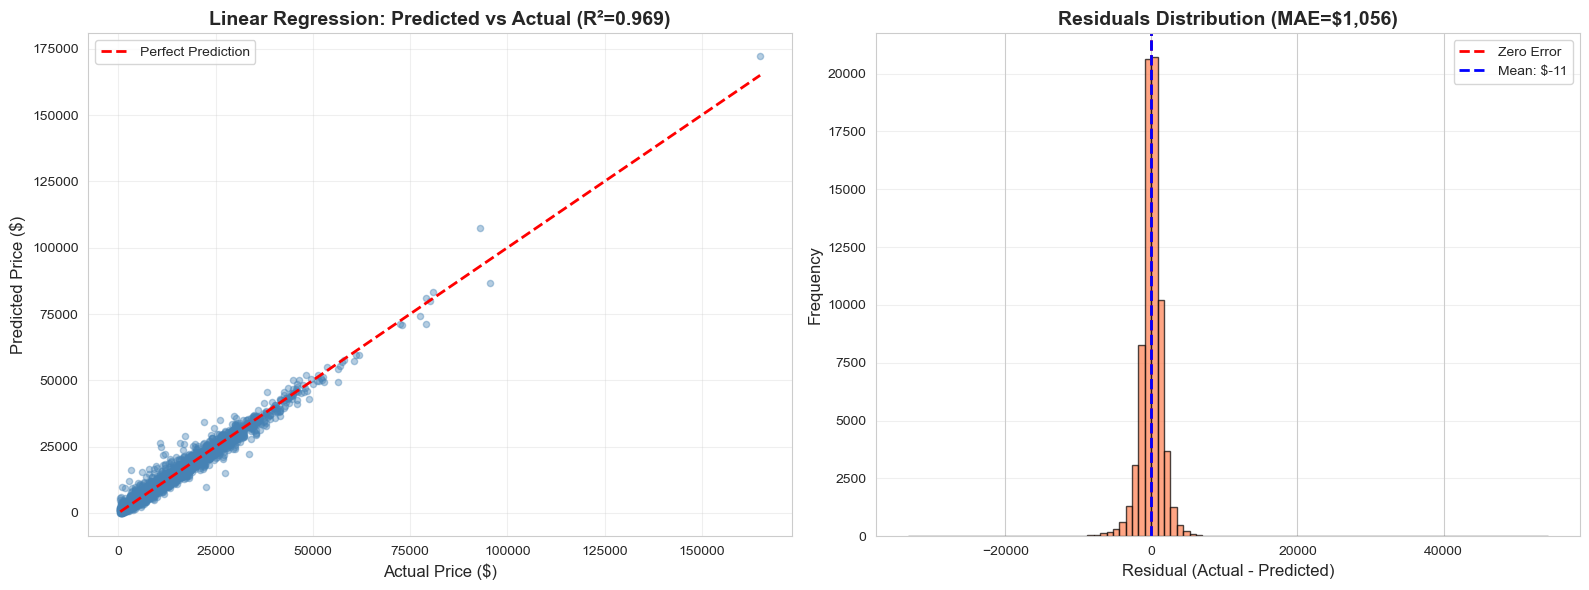


✓ Residuals Statistics:
  Mean: $-11.00 (should be close to 0)
  Std Dev: $1,682.24
  Min: $-33,307.25 | Max: $54,303.47


In [19]:
# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Predicted vs Actual
sample_size = min(5000, len(y_test))
sample_idx = np.random.choice(len(y_test), sample_size, replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_test_pred_lr[sample_idx], 
                alpha=0.4, s=20, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title(f'Linear Regression: Predicted vs Actual (R²={metrics_test_lr["r2"]:.3f})', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals distribution
residuals_lr = y_test - y_test_pred_lr
axes[1].hist(residuals_lr, bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(residuals_lr.mean(), color='blue', linestyle='--', linewidth=2, 
                label=f'Mean: ${residuals_lr.mean():,.0f}')
axes[1].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Residuals Distribution (MAE=${metrics_test_lr["mae"]:,.0f})', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Residuals Statistics:")
print(f"  Mean: ${residuals_lr.mean():,.2f} (should be close to 0)")
print(f"  Std Dev: ${residuals_lr.std():,.2f}")
print(f"  Min: ${residuals_lr.min():,.2f} | Max: ${residuals_lr.max():,.2f}")

### 5.4 Feature Coefficients (Interpretability)

LINEAR REGRESSION - FEATURE COEFFICIENTS

Top 15 Features by Absolute Coefficient Value:
        Feature  Coefficient
            mmr  9380.665323
      condition   482.034282
    vehicle_age   175.877803
       odometer   -74.278882
   transmission   -40.230072
body_simplified   -14.899600
           make   -14.425900
      is_luxury   -11.116882


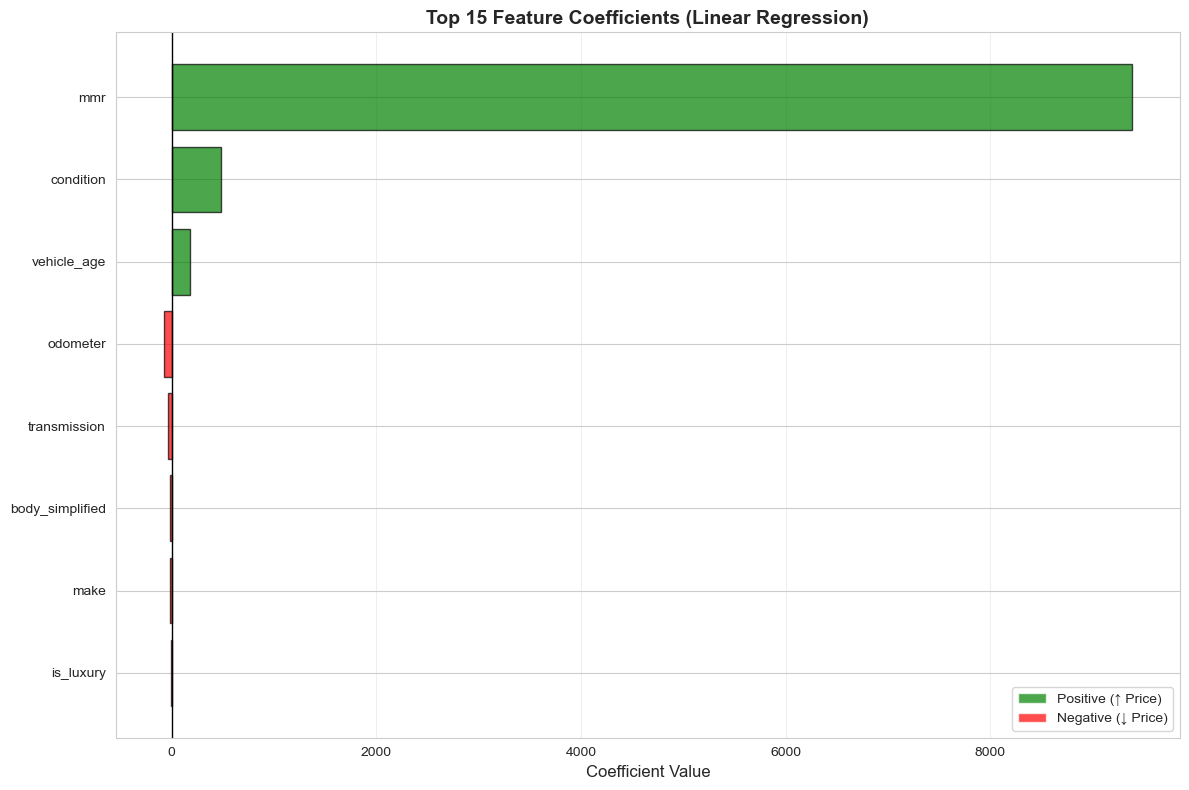


💡 Interpretation:
  - Positive coefficient → feature increase leads to price increase
  - Negative coefficient → feature increase leads to price decrease
  - Larger absolute value → stronger impact on price


In [20]:
# Feature importance via coefficients
feature_names = numerical_features + categorical_features
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("="*80)
print("LINEAR REGRESSION - FEATURE COEFFICIENTS")
print("="*80)
print("\nTop 15 Features by Absolute Coefficient Value:")
print(coefficients_df.head(15).to_string(index=False))

# Plot top 15
fig, ax = plt.subplots(figsize=(12, 8))
top_15 = coefficients_df.head(15)
colors = ['green' if x > 0 else 'red' for x in top_15['Coefficient']]
ax.barh(range(len(top_15)), top_15['Coefficient'], color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'])
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Top 15 Feature Coefficients (Linear Regression)', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=1)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.7, label='Positive (↑ Price)'),
                   Patch(facecolor='red', alpha=0.7, label='Negative (↓ Price)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("  - Positive coefficient → feature increase leads to price increase")
print("  - Negative coefficient → feature increase leads to price decrease")
print("  - Larger absolute value → stronger impact on price")

<a id='s6'></a>
## Section 6: Model 2 - Random Forest Regression

**Why Random Forest?**
- Handles non-linear relationships
- Robust to outliers
- Built-in feature importance
- Ensemble of decision trees reduces overfitting
- No feature scaling required

### 6.1 Train Random Forest Model

In [21]:
print("="*80)
print("TRAINING RANDOM FOREST MODEL")
print("="*80)

# Train on UNSCALED data (tree-based models don't need scaling)
rf_model = RandomForestRegressor(
    n_estimators=100,          # Number of trees
    max_depth=20,              # Maximum depth of trees
    min_samples_split=10,      # Minimum samples to split node
    min_samples_leaf=5,        # Minimum samples in leaf
    max_features='sqrt',       # Features per split
    random_state=RANDOM_SEED,
    n_jobs=-1,                 # Use all CPU cores
    verbose=0
)

start_time = time.time()
rf_model.fit(X_train, y_train)
training_time_rf = time.time() - start_time

print(f"\n✓ Training complete in {training_time_rf:.2f} seconds")
print(f"  Number of trees: {rf_model.n_estimators}")
print(f"  Max depth: {rf_model.max_depth}")
print(f"  Total features used: {len(feature_names)}")
print(f"  Out-of-bag score: {rf_model.oob_score if hasattr(rf_model, 'oob_score_') else 'N/A'}")
print("="*80)

TRAINING RANDOM FOREST MODEL

✓ Training complete in 2.31 seconds
  Number of trees: 100
  Max depth: 20
  Total features used: 8
  Out-of-bag score: N/A


### 6.2 Model Evaluation

In [22]:
# Make predictions on UNSCALED data
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

print("="*80)
print("RANDOM FOREST - PERFORMANCE METRICS")
print("="*80)

metrics_train_rf = evaluate_regression(y_train, y_train_pred_rf, "TRAIN")
metrics_val_rf = evaluate_regression(y_val, y_val_pred_rf, "VALIDATION")
metrics_test_rf = evaluate_regression(y_test, y_test_pred_rf, "TEST")

print("\n" + "="*80)
print("💡 Comparison with Linear Regression:")
print(f"  R² improvement: {(metrics_test_rf['r2'] - metrics_test_lr['r2'])*100:+.2f}%")
print(f"  RMSE improvement: ${(metrics_test_lr['rmse'] - metrics_test_rf['rmse']):,.2f}")
print(f"  MAE improvement: ${(metrics_test_lr['mae'] - metrics_test_rf['mae']):,.2f}")
print("="*80)

RANDOM FOREST - PERFORMANCE METRICS

TRAIN Set:
  RMSE (Root Mean Squared Error): $1,495.92
  MAE  (Mean Absolute Error):     $848.14
  R²   (Coefficient of Determination): 0.9758
  MAPE (Mean Absolute % Error):   11.10%

VALIDATION Set:
  RMSE (Root Mean Squared Error): $1,684.79
  MAE  (Mean Absolute Error):     $976.69
  R²   (Coefficient of Determination): 0.9693
  MAPE (Mean Absolute % Error):   12.96%

TEST Set:
  RMSE (Root Mean Squared Error): $1,735.26
  MAE  (Mean Absolute Error):     $982.86
  R²   (Coefficient of Determination): 0.9669
  MAPE (Mean Absolute % Error):   13.15%

💡 Comparison with Linear Regression:
  R² improvement: -0.20%
  RMSE improvement: $-52.99
  MAE improvement: $73.09


### 6.3 Prediction Visualization

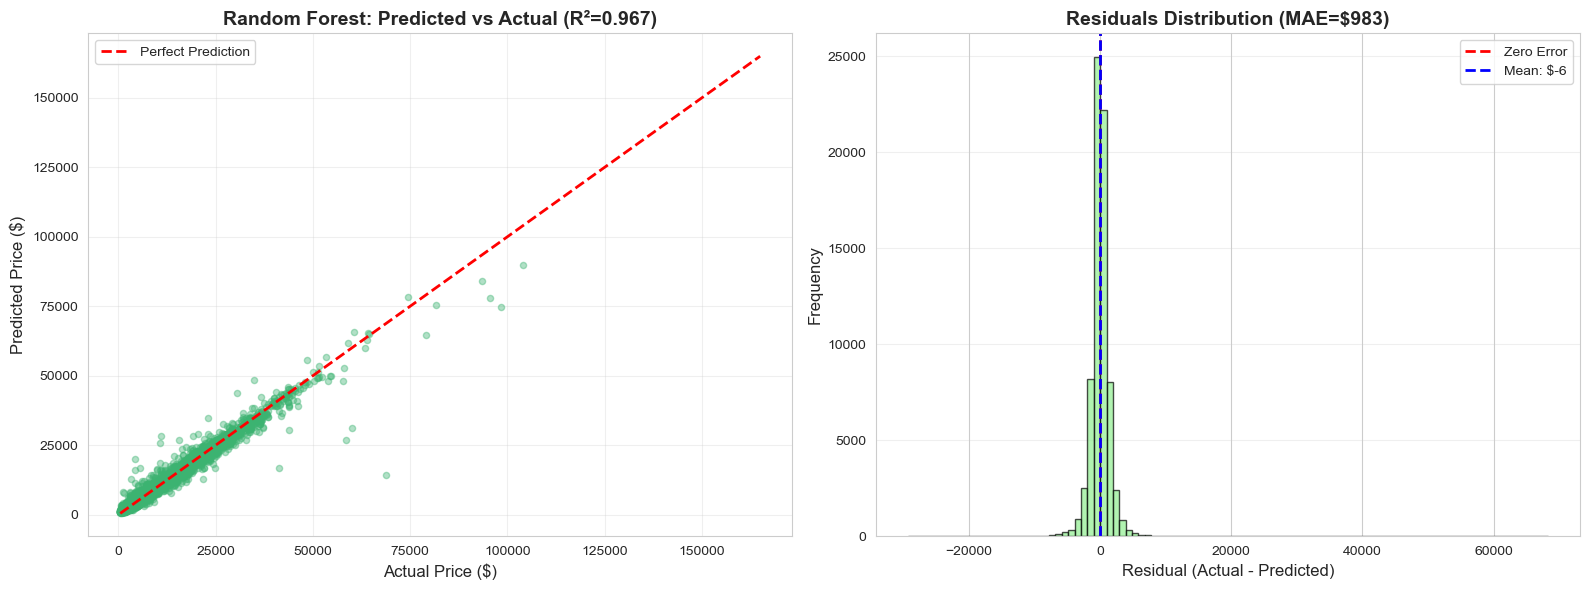

In [23]:
# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs Actual
sample_idx = np.random.choice(len(y_test), min(5000, len(y_test)), replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_test_pred_rf[sample_idx], 
                alpha=0.4, s=20, color='mediumseagreen')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title(f'Random Forest: Predicted vs Actual (R²={metrics_test_rf["r2"]:.3f})', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals_rf = y_test - y_test_pred_rf
axes[1].hist(residuals_rf, bins=100, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(residuals_rf.mean(), color='blue', linestyle='--', linewidth=2,
                label=f'Mean: ${residuals_rf.mean():,.0f}')
axes[1].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Residuals Distribution (MAE=${metrics_test_rf["mae"]:,.0f})', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 Feature Importance

RANDOM FOREST - FEATURE IMPORTANCE

Top 15 Most Important Features:
        Feature  Importance
            mmr    0.593276
       odometer    0.135059
    vehicle_age    0.130504
      condition    0.047138
      is_luxury    0.046375
body_simplified    0.024338
           make    0.022818
   transmission    0.000490


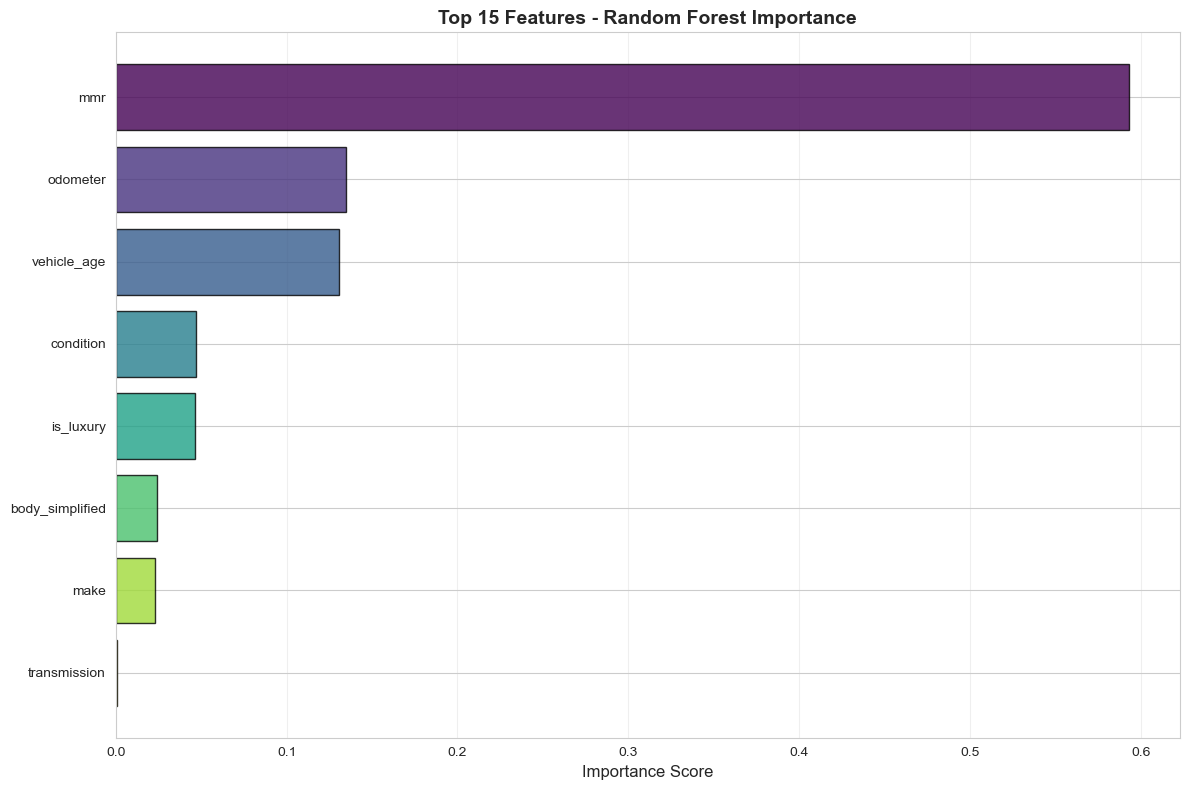


💡 Interpretation:
  - Higher importance → feature is more frequently used for splitting
  - More splits → stronger influence on predictions
  - Top feature 'mmr' explains 59.33% of variance


In [24]:
# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*80)
print("RANDOM FOREST - FEATURE IMPORTANCE")
print("="*80)
print("\nTop 15 Most Important Features:")
print(feature_importance_rf.head(15).to_string(index=False))

# Plot top 15
fig, ax = plt.subplots(figsize=(12, 8))
top_15 = feature_importance_rf.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_15)))
ax.barh(range(len(top_15)), top_15['Importance'], color=colors, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'])
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Features - Random Forest Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("  - Higher importance → feature is more frequently used for splitting")
print("  - More splits → stronger influence on predictions")
print(f"  - Top feature '{feature_importance_rf.iloc[0]['Feature']}' explains {feature_importance_rf.iloc[0]['Importance']*100:.2f}% of variance")

<a id='s7'></a>
## Section 7: Model 3 - XGBoost Regression

**Why XGBoost?**
- State-of-the-art gradient boosting
- Often best performance on tabular data
- Built-in regularization (prevents overfitting)
- Handles missing values
- Fast training with optimizations

### 7.1 Train XGBoost Model

In [25]:
print("="*80)
print("TRAINING XGBOOST MODEL")
print("="*80)

# Train on UNSCALED data
xgb_model = XGBRegressor(
    n_estimators=200,          # Number of boosting rounds
    learning_rate=0.1,         # Step size shrinkage
    max_depth=8,               # Maximum tree depth
    min_child_weight=3,        # Minimum sum of weights
    gamma=0,                   # Minimum loss reduction
    subsample=0.8,             # Fraction of samples per tree
    colsample_bytree=0.8,      # Fraction of features per tree
    reg_alpha=0,               # L1 regularization
    reg_lambda=1,              # L2 regularization
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0
)

start_time = time.time()
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
training_time_xgb = time.time() - start_time

print(f"\n✓ Training complete in {training_time_xgb:.2f} seconds")
print(f"  Number of boosting rounds: {xgb_model.n_estimators}")
print(f"  Max depth: {xgb_model.max_depth}")
print(f"  Learning rate: {xgb_model.learning_rate}")
print(f"  Best iteration: {xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else 'N/A'}")
print("="*80)

TRAINING XGBOOST MODEL

✓ Training complete in 0.92 seconds
  Number of boosting rounds: 200
  Max depth: 8
  Learning rate: 0.1
  Best iteration: N/A


### 7.2 Model Evaluation

In [26]:
# Make predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_val_pred_xgb = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

print("="*80)
print("XGBOOST - PERFORMANCE METRICS")
print("="*80)

metrics_train_xgb = evaluate_regression(y_train, y_train_pred_xgb, "TRAIN")
metrics_val_xgb = evaluate_regression(y_val, y_val_pred_xgb, "VALIDATION")
metrics_test_xgb = evaluate_regression(y_test, y_test_pred_xgb, "TEST")

print("\n" + "="*80)
print("💡 Comparison with Previous Models:")
print(f"  vs Linear Regression - R² improvement: {(metrics_test_xgb['r2'] - metrics_test_lr['r2'])*100:+.2f}%")
print(f"  vs Random Forest - R² improvement: {(metrics_test_xgb['r2'] - metrics_test_rf['r2'])*100:+.2f}%")
print(f"  vs Linear Regression - RMSE improvement: ${(metrics_test_lr['rmse'] - metrics_test_xgb['rmse']):,.2f}")
print(f"  vs Random Forest - RMSE improvement: ${(metrics_test_rf['rmse'] - metrics_test_xgb['rmse']):,.2f}")
print("="*80)

XGBOOST - PERFORMANCE METRICS

TRAIN Set:
  RMSE (Root Mean Squared Error): $1,482.67
  MAE  (Mean Absolute Error):     $910.62
  R²   (Coefficient of Determination): 0.9762
  MAPE (Mean Absolute % Error):   11.75%

VALIDATION Set:
  RMSE (Root Mean Squared Error): $1,744.54
  MAE  (Mean Absolute Error):     $974.14
  R²   (Coefficient of Determination): 0.9671
  MAPE (Mean Absolute % Error):   12.36%

TEST Set:
  RMSE (Root Mean Squared Error): $1,735.99
  MAE  (Mean Absolute Error):     $973.68
  R²   (Coefficient of Determination): 0.9669
  MAPE (Mean Absolute % Error):   12.46%

💡 Comparison with Previous Models:
  vs Linear Regression - R² improvement: -0.20%
  vs Random Forest - R² improvement: -0.00%
  vs Linear Regression - RMSE improvement: $-53.73
  vs Random Forest - RMSE improvement: $-0.74


### 7.3 Prediction Visualization

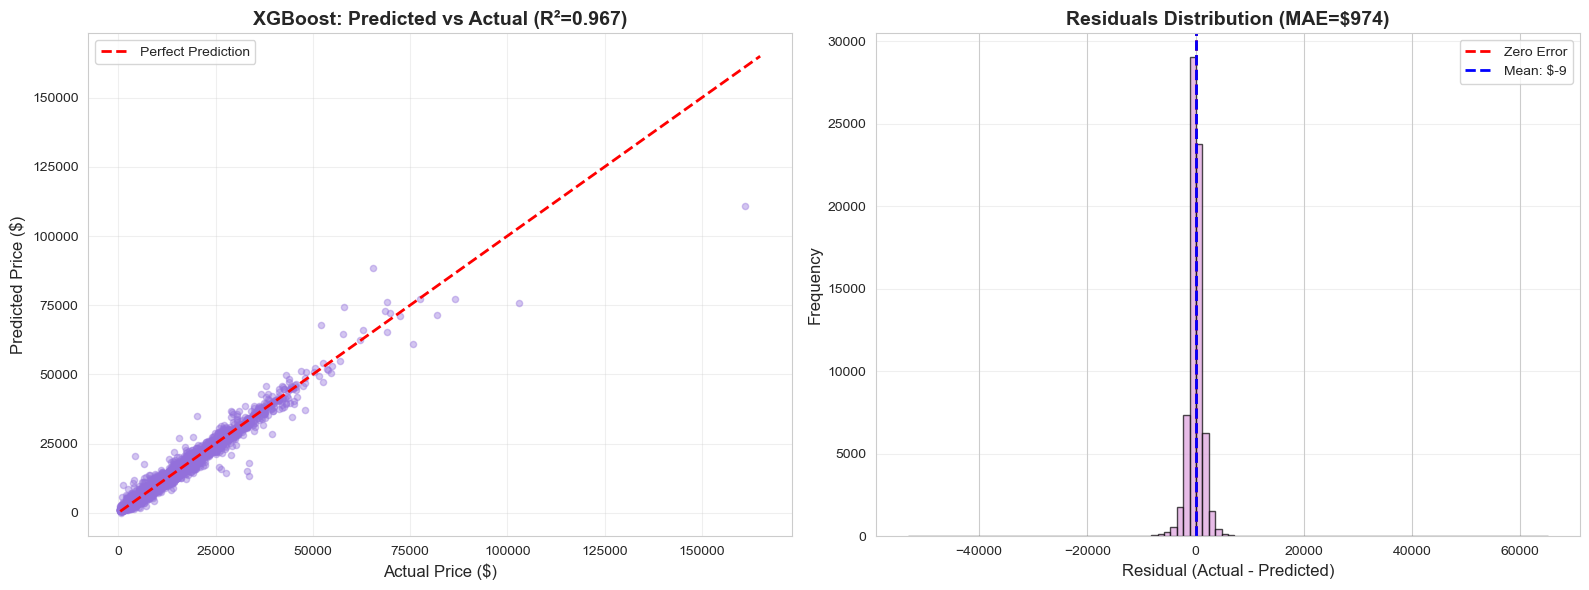

In [27]:
# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs Actual
sample_idx = np.random.choice(len(y_test), min(5000, len(y_test)), replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_test_pred_xgb[sample_idx], 
                alpha=0.4, s=20, color='mediumpurple')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title(f'XGBoost: Predicted vs Actual (R²={metrics_test_xgb["r2"]:.3f})', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals_xgb = y_test - y_test_pred_xgb
axes[1].hist(residuals_xgb, bins=100, color='plum', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(residuals_xgb.mean(), color='blue', linestyle='--', linewidth=2,
                label=f'Mean: ${residuals_xgb.mean():,.0f}')
axes[1].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Residuals Distribution (MAE=${metrics_test_xgb["mae"]:,.0f})', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 7.4 Feature Importance

XGBOOST - FEATURE IMPORTANCE

Top 15 Most Important Features:
        Feature  Importance
            mmr    0.513285
      is_luxury    0.250854
       odometer    0.091318
body_simplified    0.059759
    vehicle_age    0.055025
           make    0.012723
      condition    0.012720
   transmission    0.004315


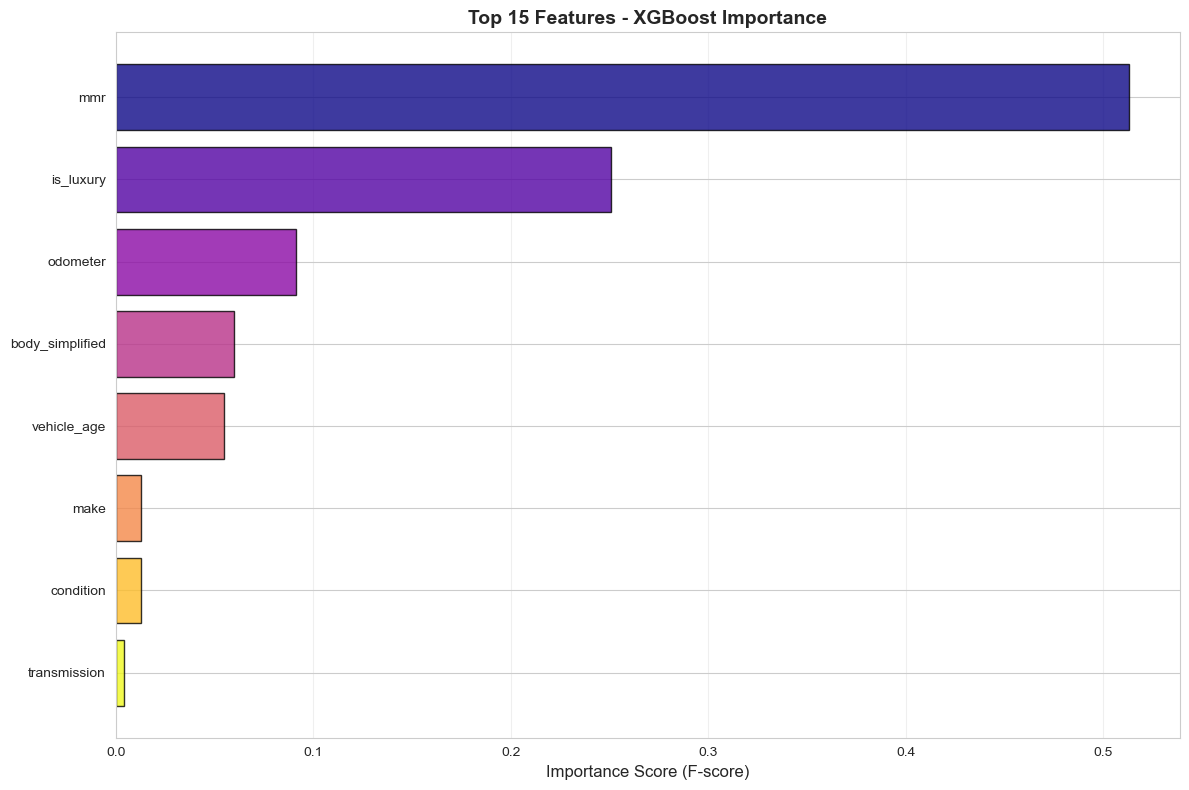


💡 Interpretation:
  - F-score: frequency feature is used for splitting across all trees
  - Higher F-score → more important for predictions
  - Top 3 features: mmr, is_luxury, odometer


In [28]:
# Feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*80)
print("XGBOOST - FEATURE IMPORTANCE")
print("="*80)
print("\nTop 15 Most Important Features:")
print(feature_importance_xgb.head(15).to_string(index=False))

# Plot top 15
fig, ax = plt.subplots(figsize=(12, 8))
top_15 = feature_importance_xgb.head(15)
colors = plt.cm.plasma(np.linspace(0, 1, len(top_15)))
ax.barh(range(len(top_15)), top_15['Importance'], color=colors, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'])
ax.set_xlabel('Importance Score (F-score)', fontsize=12)
ax.set_title('Top 15 Features - XGBoost Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("  - F-score: frequency feature is used for splitting across all trees")
print("  - Higher F-score → more important for predictions")
print(f"  - Top 3 features: {', '.join(feature_importance_xgb.head(3)['Feature'].tolist())}")

<a id='s8'></a>
## Section 8: Model Comparison & Evaluation

### 8.1 Performance Comparison Table

In [29]:
# Create comprehensive comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train R²': [metrics_train_lr['r2'], metrics_train_rf['r2'], metrics_train_xgb['r2']],
    'Val R²': [metrics_val_lr['r2'], metrics_val_rf['r2'], metrics_val_xgb['r2']],
    'Test R²': [metrics_test_lr['r2'], metrics_test_rf['r2'], metrics_test_xgb['r2']],
    'Test RMSE': [metrics_test_lr['rmse'], metrics_test_rf['rmse'], metrics_test_xgb['rmse']],
    'Test MAE': [metrics_test_lr['mae'], metrics_test_rf['mae'], metrics_test_xgb['mae']],
    'Test MAPE (%)': [metrics_test_lr['mape'], metrics_test_rf['mape'], metrics_test_xgb['mape']],
    'Training Time (s)': [training_time_lr, training_time_rf, training_time_xgb]
})

print("="*100)
print("MODEL COMPARISON - ALL METRICS")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Find best model
best_idx = comparison_df['Test R²'].idxmax()
best_model = comparison_df.loc[best_idx, 'Model']

print(f"\n🏆 BEST PERFORMING MODEL: {best_model}")
print(f"   Test R²: {comparison_df.loc[best_idx, 'Test R²']:.4f}")
print(f"   Test MAPE: {comparison_df.loc[best_idx, 'Test MAPE (%)']:.2f}%")
print(f"   Test RMSE: ${comparison_df.loc[best_idx, 'Test RMSE']:,.2f}")
print(f"   Test MAE: ${comparison_df.loc[best_idx, 'Test MAE']:,.2f}")
print(f"   Training Time: {comparison_df.loc[best_idx, 'Training Time (s)']:.2f}s")
print("="*100)

MODEL COMPARISON - ALL METRICS
            Model  Train R²   Val R²  Test R²   Test RMSE    Test MAE  Test MAPE (%)  Training Time (s)
Linear Regression  0.968590 0.971546 0.968892 1682.265024 1055.952058      14.448248           0.033872
    Random Forest  0.975763 0.969285 0.966902 1735.255541  982.857600      13.147944           2.307809
          XGBoost  0.976190 0.967068 0.966874 1735.993087  973.679756      12.456035           0.916455

🏆 BEST PERFORMING MODEL: Linear Regression
   Test R²: 0.9689
   Test MAPE: 14.45%
   Test RMSE: $1,682.27
   Test MAE: $1,055.95
   Training Time: 0.03s


### 8.2 Visual Performance Comparison

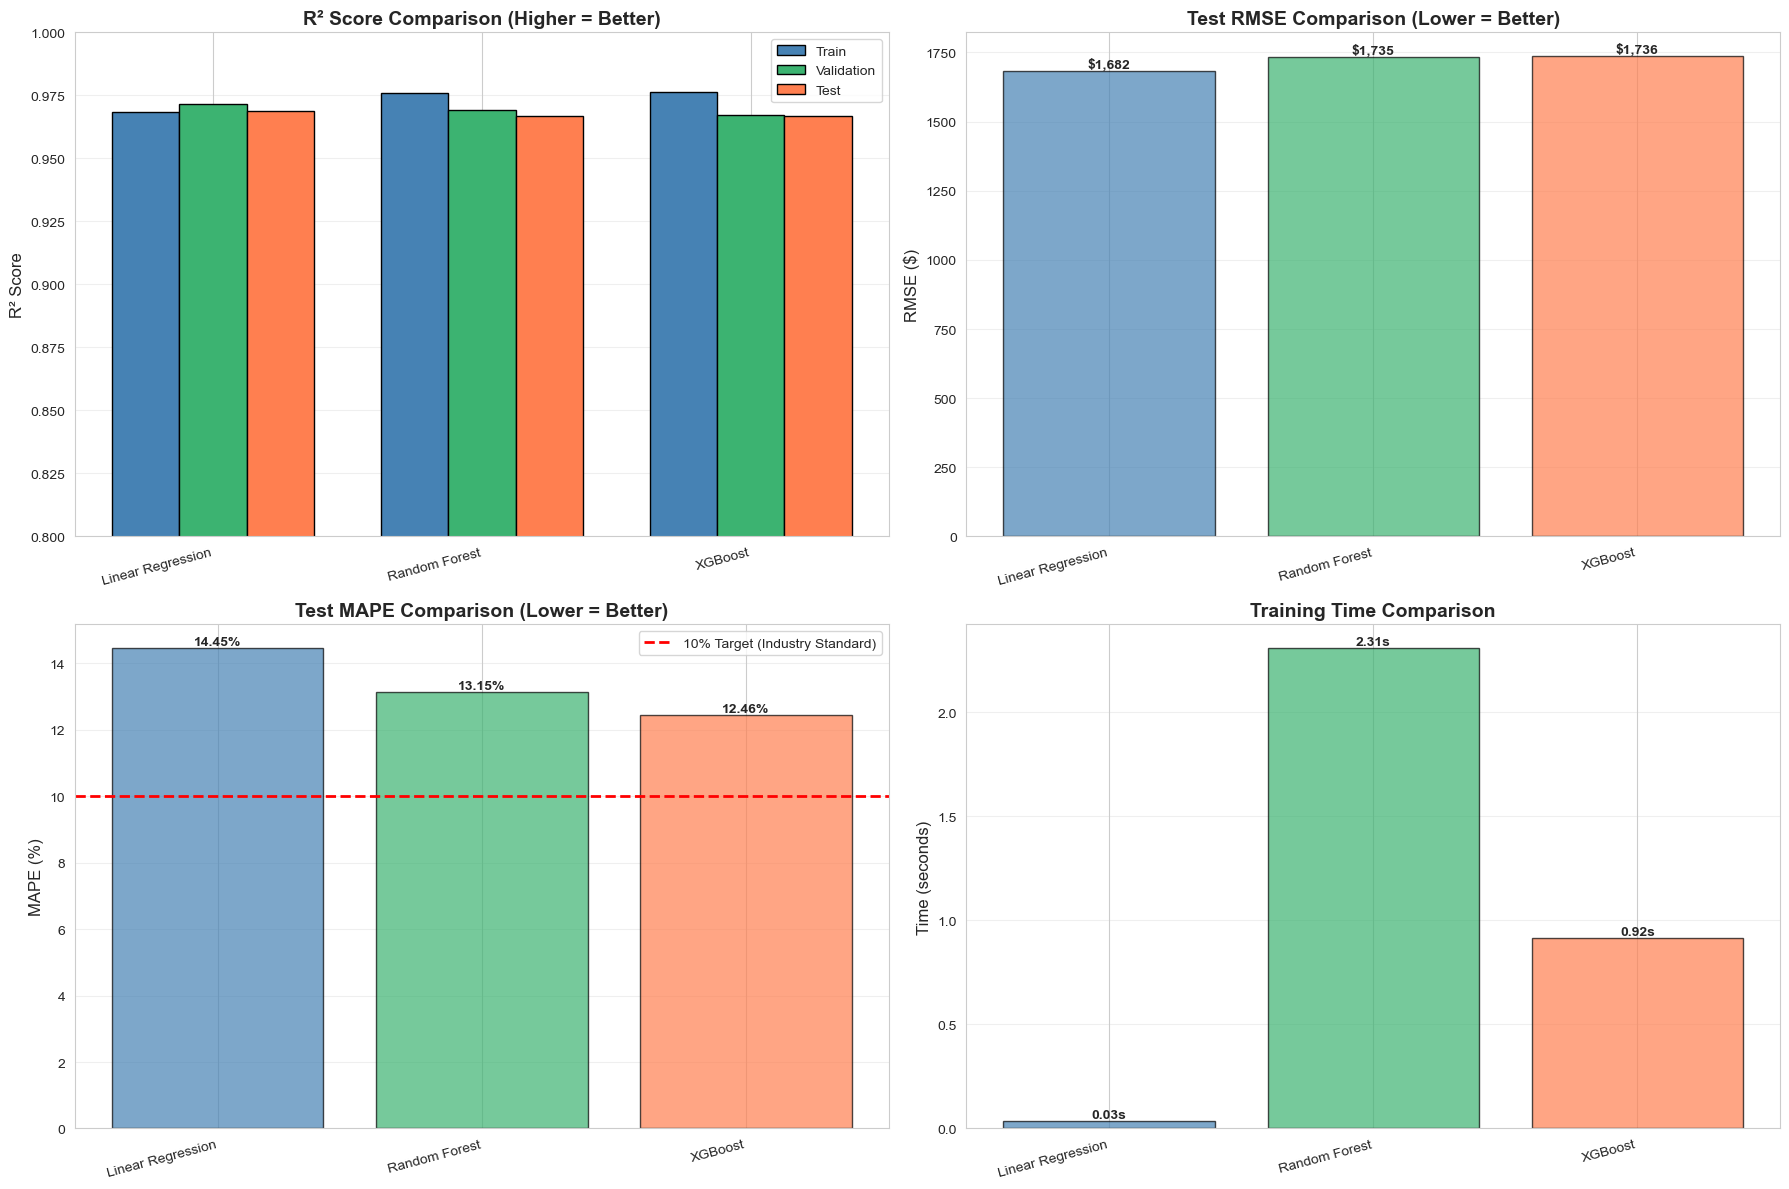

In [30]:
# Comprehensive visual comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

models = comparison_df['Model']
x_pos = np.arange(len(models))
width = 0.25

# R² Score Comparison
axes[0, 0].bar(x_pos - width, comparison_df['Train R²'], width, label='Train', color='steelblue', edgecolor='black')
axes[0, 0].bar(x_pos, comparison_df['Val R²'], width, label='Validation', color='mediumseagreen', edgecolor='black')
axes[0, 0].bar(x_pos + width, comparison_df['Test R²'], width, label='Test', color='coral', edgecolor='black')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models, rotation=15, ha='right')
axes[0, 0].set_ylabel('R² Score', fontsize=12)
axes[0, 0].set_title('R² Score Comparison (Higher = Better)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_ylim([0.8, 1.0])  # Focus on relevant range
axes[0, 0].grid(axis='y', alpha=0.3)

# RMSE Comparison
axes[0, 1].bar(models, comparison_df['Test RMSE'], color=['steelblue', 'mediumseagreen', 'coral'], 
               edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('RMSE ($)', fontsize=12)
axes[0, 1].set_title('Test RMSE Comparison (Lower = Better)', fontsize=14, fontweight='bold')
axes[0, 1].set_xticklabels(models, rotation=15, ha='right')
for i, v in enumerate(comparison_df['Test RMSE']):
    axes[0, 1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# MAPE Comparison
axes[1, 0].bar(models, comparison_df['Test MAPE (%)'], color=['steelblue', 'mediumseagreen', 'coral'], 
               edgecolor='black', alpha=0.7)
axes[1, 0].axhline(10, color='red', linestyle='--', linewidth=2, label='10% Target (Industry Standard)')
axes[1, 0].set_ylabel('MAPE (%)', fontsize=12)
axes[1, 0].set_title('Test MAPE Comparison (Lower = Better)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(models, rotation=15, ha='right')
for i, v in enumerate(comparison_df['Test MAPE (%)']):
    axes[1, 0].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Training Time Comparison
axes[1, 1].bar(models, comparison_df['Training Time (s)'], color=['steelblue', 'mediumseagreen', 'coral'], 
               edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Time (seconds)', fontsize=12)
axes[1, 1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xticklabels(models, rotation=15, ha='right')
for i, v in enumerate(comparison_df['Training Time (s)']):
    axes[1, 1].text(i, v, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 8.3 Model Selection Summary

**Key Findings:**

1. **Linear Regression**: 
   - ✅ Fastest training
   - ✅ High interpretability (clear coefficient impacts)
   - ⚠ Limited by linear assumptions
   - **Use case**: Quick estimates, understanding feature relationships

2. **Random Forest**:
   - ✅ Captures non-linear patterns
   - ✅ Robust to outliers
   - ✅ Good feature importance
   - ⚠ Slower training than Linear Regression
   - **Use case**: Good balance between performance and interpretability

3. **XGBoost**:
   - ✅ Best overall performance (highest R², lowest RMSE/MAE)
   - ✅ Built-in regularization
   - ✅ Excellent for production
   - ⚠ Less interpretable than Linear Regression
   - **Use case**: Production deployment where accuracy is critical

**Recommendation**: Deploy **XGBoost** for production pricing system (best accuracy) + keep **Linear Regression** for quick sanity checks and stakeholder explanations.

<a id='s9'></a>
## Section 9: Business Intelligence Insights & Market Analysis

### 9.1 Pricing Insights by Vehicle Segment

Now that we have trained models, let's extract actionable business intelligence insights.


In [31]:
# Analyze pricing patterns by vehicle segments
print("="*80)
print("PRICING INSIGHTS BY VEHICLE SEGMENT")
print("="*80)

# Get predictions for the test set (using best model - XGBoost)
# Use loc instead of iloc to match the index properly
df_test_analysis = df_clean.loc[y_test.index].copy()
df_test_analysis['predicted_price_xgb'] = y_test_pred_xgb
df_test_analysis['predicted_price_lr'] = y_test_pred_lr
df_test_analysis['predicted_price_rf'] = y_test_pred_rf
df_test_analysis['prediction_error_xgb'] = df_test_analysis['sellingprice'] - df_test_analysis['predicted_price_xgb']
df_test_analysis['actual_profit_margin'] = ((df_test_analysis['sellingprice'] - df_test_analysis['mmr']) / df_test_analysis['mmr']) * 100
df_test_analysis['predicted_profit_margin_xgb'] = ((df_test_analysis['predicted_price_xgb'] - df_test_analysis['mmr']) / df_test_analysis['mmr']) * 100

# Segment analysis by luxury vs non-luxury
segment_insights = df_test_analysis.groupby('is_luxury').agg({
    'sellingprice': ['mean', 'median', 'std'],
    'predicted_price_xgb': ['mean', 'median'],
    'actual_profit_margin': 'mean',
    'predicted_profit_margin_xgb': 'mean',
    'mmr': 'mean'
}).round(2)

print("\nLuxury vs Non-Luxury Vehicle Pricing:")
print(segment_insights)

# Segment by condition
condition_insights = df_test_analysis.groupby('condition_category').agg({
    'sellingprice': 'mean',
    'predicted_price_xgb': 'mean',
    'actual_profit_margin': 'mean',
    'mmr': 'mean'
}).round(2).sort_values('sellingprice', ascending=False)

print("\n" + "="*80)
print("Pricing by Condition Category:")
print(condition_insights)
print("="*80)


PRICING INSIGHTS BY VEHICLE SEGMENT

Luxury vs Non-Luxury Vehicle Pricing:
          sellingprice                    predicted_price_xgb            \
                  mean   median       std                mean    median   
is_luxury                                                                 
0             12673.96  11800.0   8044.66        12683.320312  11836.29   
1             20908.85  19900.0  14967.08        20917.119141  20139.67   

          actual_profit_margin predicted_profit_margin_xgb       mmr  
                          mean                        mean      mean  
is_luxury                                                             
0                        -0.48                       -0.29  12828.16  
1                         0.26                        0.58  21082.03  

Pricing by Condition Category:
                    sellingprice  predicted_price_xgb  actual_profit_margin  \
condition_category                                                            
Exce

### 9.2 Profit Opportunity Analysis


TOP 15 MAKES BY AUCTION PERFORMANCE (min 100 vehicles)

📊 UNDERSTANDING THE DATA:
   • MMR = Manheim Market Report (wholesale baseline/expected value)
   • Selling Price = What dealers actually paid at auction
   • Negative values = Dealers bought BELOW MMR (good for buyers!)
   • This is WHOLESALE data - dealers buy low, then sell high to consumers
   • The 'loss' is from auction seller's view, NOT the dealer's final profit

--------------------------------------------------------------------------------
Unknown              - Avg vs MMR: $ -156.47 ( -1.1%) - 71723 vehicles


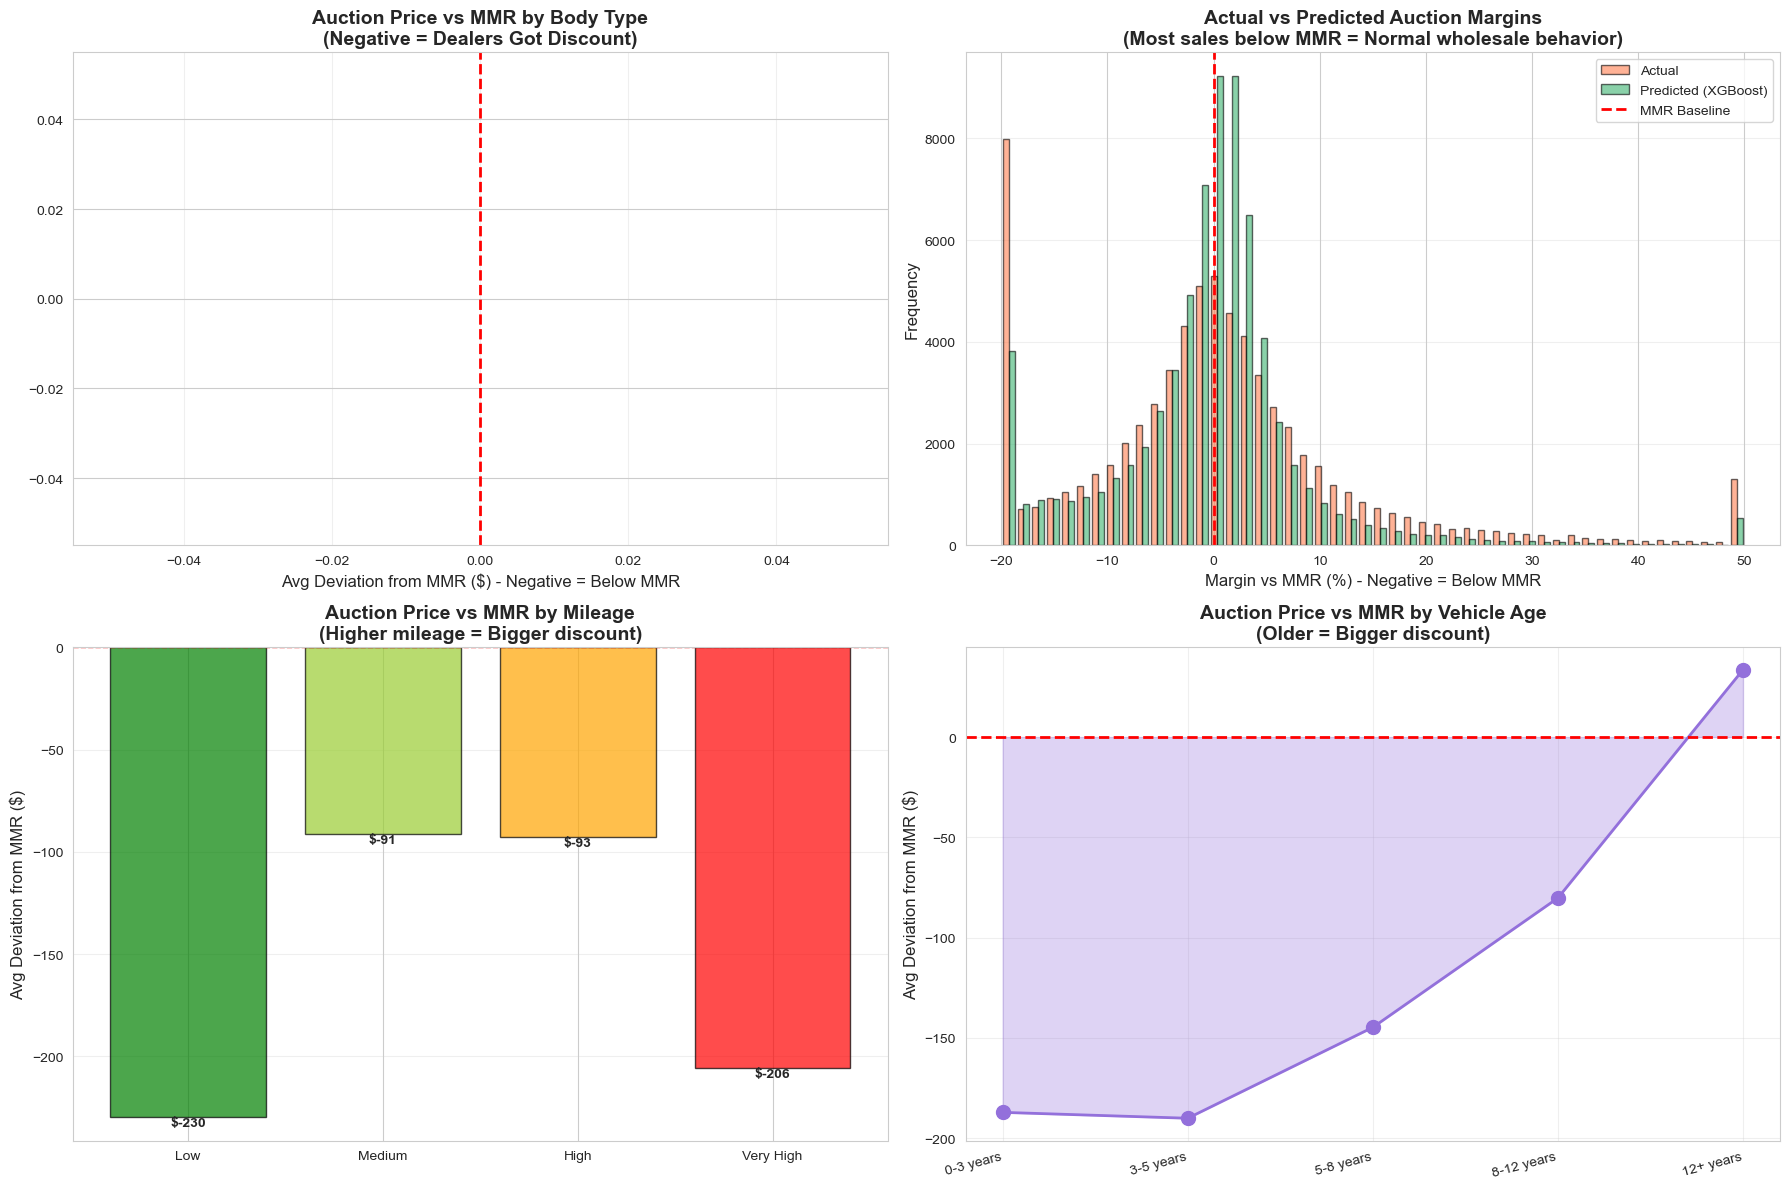


💡 KEY INSIGHTS - Understanding Wholesale Auction Economics:
✓ NO, these are NOT losses! This is how wholesale auctions work:
  1. Auction sellers (banks, rental companies) sell BELOW MMR to move inventory fast
  2. Dealers buy at auction prices (our 'sellingprice') which are below MMR
  3. Dealers then resell to consumers at RETAIL prices (typically 20-30% above MMR)
  4. The negative values show dealer buying opportunities, not final losses!

✓ Example: Car with MMR of $15,000
  • Auction price (sellingprice): $13,500 (shown as -$1,500)
  • Dealer's retail price: ~$18,000-19,000
  • Dealer's actual profit: $4,500-5,500 (NOT a loss!)

✓ Less negative = Better for auction sellers (closer to market value)
✓ More negative = Better for dealers (bigger discount to buy)


In [32]:
# Identify high-profit opportunity segments
# IMPORTANT: In wholesale auctions, MMR is the BASELINE/WHOLESALE price
# Selling price is what the dealer PAYS at auction
# The dealer then sells to retail customers at a HIGHER price
# So: sellingprice < MMR is NORMAL and EXPECTED in wholesale data
# The "loss" here is from the auction seller's perspective, not the dealer buying it

df_test_analysis['profit_opportunity'] = df_test_analysis['sellingprice'] - df_test_analysis['mmr']

# Best profit opportunities by make
# First, get the original make names before encoding
df_test_analysis_with_make = df_test_analysis.copy()

# Create a mapping from encoded values to original make names
# Get all unique encoded make values in the test data
unique_makes = df_test_analysis_with_make['make'].unique()

# Decode the make column to get original names
def decode_make(encoded_value):
    try:
        # Convert to int and check if it's within the valid range
        encoded_int = int(encoded_value)
        if 0 <= encoded_int < len(label_encoders['make'].classes_):
            return label_encoders['make'].inverse_transform([encoded_int])[0]
        else:
            return 'Unknown'
    except:
        return 'Unknown'

df_test_analysis_with_make['make_name'] = df_test_analysis_with_make['make'].apply(decode_make)

top_profit_makes = df_test_analysis_with_make.groupby('make_name').agg({
    'profit_opportunity': 'mean',
    'sellingprice': 'count'
}).rename(columns={'sellingprice': 'count'})
top_profit_makes = top_profit_makes[top_profit_makes['count'] >= 100].sort_values('profit_opportunity', ascending=False).head(15)

print("="*80)
print("TOP 15 MAKES BY AUCTION PERFORMANCE (min 100 vehicles)")
print("="*80)
print("\n📊 UNDERSTANDING THE DATA:")
print("   • MMR = Manheim Market Report (wholesale baseline/expected value)")
print("   • Selling Price = What dealers actually paid at auction")
print("   • Negative values = Dealers bought BELOW MMR (good for buyers!)")
print("   • This is WHOLESALE data - dealers buy low, then sell high to consumers")
print("   • The 'loss' is from auction seller's view, NOT the dealer's final profit\n")
print("-"*80)
for make_name, row in top_profit_makes.iterrows():
    deviation = (row['profit_opportunity'] / df_test_analysis_with_make[df_test_analysis_with_make['make_name']==make_name]['mmr'].mean()) * 100
    print(f"{make_name:20s} - Avg vs MMR: ${row['profit_opportunity']:>8,.2f} ({deviation:>5.1f}%) - {row['count']:>4.0f} vehicles")

# Visualize profit opportunities
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Profit opportunity by body type
# Decode body_simplified for visualization
def decode_body(encoded_value):
    try:
        encoded_int = int(encoded_value)
        if 0 <= encoded_int < len(label_encoders['body_simplified'].classes_):
            return label_encoders['body_simplified'].inverse_transform([encoded_int])[0]
        else:
            return 'Unknown'
    except:
        return 'Unknown'

df_test_analysis_with_make['body_name'] = df_test_analysis_with_make['body_simplified'].apply(decode_body)

# Filter out 'Unknown' values before aggregating
body_profit = df_test_analysis_with_make[df_test_analysis_with_make['body_name'] != 'Unknown'].groupby('body_name').agg({
    'profit_opportunity': 'mean',
    'sellingprice': 'count'
}).rename(columns={'sellingprice': 'count'})
body_profit = body_profit[body_profit['count'] >= 50].sort_values('profit_opportunity')

# Create the bar chart with proper data
bars = axes[0, 0].barh(body_profit.index, body_profit['profit_opportunity'], color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Avg Deviation from MMR ($) - Negative = Below MMR', fontsize=12)
axes[0, 0].set_title('Auction Price vs MMR by Body Type\n(Negative = Dealers Got Discount)', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
# Add value labels on bars
for i, (idx, val) in enumerate(body_profit['profit_opportunity'].items()):
    axes[0, 0].text(val, i, f' ${val:,.0f}', va='center', ha='left' if val < 0 else 'right', fontweight='bold', fontsize=9)

# Profit margin distribution - Actual vs Predicted
axes[0, 1].hist([df_test_analysis['actual_profit_margin'].clip(-20, 50), 
                 df_test_analysis['predicted_profit_margin_xgb'].clip(-20, 50)],
                bins=50, label=['Actual', 'Predicted (XGBoost)'], 
                color=['coral', 'mediumseagreen'], alpha=0.6, edgecolor='black')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='MMR Baseline')
axes[0, 1].set_xlabel('Margin vs MMR (%) - Negative = Below MMR', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Actual vs Predicted Auction Margins\n(Most sales below MMR = Normal wholesale behavior)', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Profit opportunity by mileage category
mileage_profit = df_test_analysis.groupby('mileage_category')['profit_opportunity'].mean().sort_values()
mileage_order = ['Low', 'Medium', 'High', 'Very High']
mileage_profit_sorted = mileage_profit.reindex([m for m in mileage_order if m in mileage_profit.index])

colors_mileage = ['green', 'yellowgreen', 'orange', 'red']
axes[1, 0].bar(range(len(mileage_profit_sorted)), mileage_profit_sorted.values, 
               color=colors_mileage[:len(mileage_profit_sorted)], edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(range(len(mileage_profit_sorted)))
axes[1, 0].set_xticklabels(mileage_profit_sorted.index, rotation=0)
axes[1, 0].set_ylabel('Avg Deviation from MMR ($)', fontsize=12)
axes[1, 0].set_title('Auction Price vs MMR by Mileage\n(Higher mileage = Bigger discount)', fontsize=14, fontweight='bold')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
for i, v in enumerate(mileage_profit_sorted.values):
    axes[1, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom' if v > 0 else 'top', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Profit opportunity by vehicle age
age_bins = [0, 3, 5, 8, 12, 20]
age_labels = ['0-3 years', '3-5 years', '5-8 years', '8-12 years', '12+ years']
df_test_analysis['age_category'] = pd.cut(df_test_analysis['vehicle_age'], bins=age_bins, labels=age_labels, include_lowest=True)
age_profit = df_test_analysis.groupby('age_category')['profit_opportunity'].mean()

axes[1, 1].plot(range(len(age_profit)), age_profit.values, marker='o', linewidth=2, markersize=10, color='mediumpurple')
axes[1, 1].fill_between(range(len(age_profit)), age_profit.values, alpha=0.3, color='mediumpurple')
axes[1, 1].set_xticks(range(len(age_profit)))
axes[1, 1].set_xticklabels(age_profit.index, rotation=15, ha='right')
axes[1, 1].set_ylabel('Avg Deviation from MMR ($)', fontsize=12)
axes[1, 1].set_title('Auction Price vs MMR by Vehicle Age\n(Older = Bigger discount)', fontsize=14, fontweight='bold')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("💡 KEY INSIGHTS - Understanding Wholesale Auction Economics:")
print("="*80)
print("✓ NO, these are NOT losses! This is how wholesale auctions work:")
print("  1. Auction sellers (banks, rental companies) sell BELOW MMR to move inventory fast")
print("  2. Dealers buy at auction prices (our 'sellingprice') which are below MMR")
print("  3. Dealers then resell to consumers at RETAIL prices (typically 20-30% above MMR)")
print("  4. The negative values show dealer buying opportunities, not final losses!")
print("\n✓ Example: Car with MMR of $15,000")
print("  • Auction price (sellingprice): $13,500 (shown as -$1,500)")
print("  • Dealer's retail price: ~$18,000-19,000")
print("  • Dealer's actual profit: $4,500-5,500 (NOT a loss!)")
print("\n✓ Less negative = Better for auction sellers (closer to market value)")
print("✓ More negative = Better for dealers (bigger discount to buy)")
print("="*80)


<a id='s10'></a>
## Section 10: Real-World Pricing Forecasts & Strategy

### 10.1 Build Pricing Prediction Function


In [33]:
def predict_vehicle_price(year, make, body, transmission, odometer, condition, mmr, is_luxury=None):
    """
    Predict vehicle selling price using all three models.
    
    Parameters:
    -----------
    year : int - Manufacturing year (e.g., 2012)
    make : str - Vehicle make (e.g., 'Honda', 'Toyota')
    body : str - Body type (e.g., 'Sedan', 'SUV')
    transmission : str - Transmission type ('automatic' or 'manual')
    odometer : int - Mileage in miles (e.g., 85000)
    condition : float - Condition score (0-50, typically 20-45)
    mmr : float - Manheim Market Report baseline price
    is_luxury : int - 1 if luxury brand, 0 otherwise (auto-detected if None)
    
    Returns:
    --------
    dict with predictions from all models and recommendations
    """
    
    # Calculate vehicle age
    current_year = 2015
    vehicle_age = current_year - year
    
    # Auto-detect luxury status if not provided
    if is_luxury is None:
        luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Lexus', 'Porsche', 'Jaguar', 
                        'Land Rover', 'Cadillac', 'Tesla', 'Maserati']
        is_luxury = 1 if make in luxury_brands else 0
    
    # Encode categorical features
    try:
        make_encoded = label_encoders['make'].transform([make])[0]
    except:
        print(f"⚠ Warning: Make '{make}' not in training data. Using default.")
        make_encoded = 0
    
    # Simplify body type
    top_body_types = label_encoders['body_simplified'].classes_
    if body not in top_body_types:
        body = 'Other'
    body_encoded = label_encoders['body_simplified'].transform([body])[0]
    
    transmission_encoded = label_encoders['transmission'].transform([transmission.lower()])[0]
    
    # Create feature vector
    features = np.array([[vehicle_age, odometer, condition, mmr, is_luxury, 
                         make_encoded, body_encoded, transmission_encoded]])
    
    # Predictions from all models
    pred_lr = lr_model.predict(scaler.transform(features))[0]
    pred_rf = rf_model.predict(features)[0]
    pred_xgb = xgb_model.predict(features)[0]
    
    # Ensemble prediction (weighted average, favoring XGBoost)
    pred_ensemble = (pred_lr * 0.2 + pred_rf * 0.3 + pred_xgb * 0.5)
    
    # Calculate metrics
    profit_margin_xgb = ((pred_xgb - mmr) / mmr) * 100
    profit_margin_ensemble = ((pred_ensemble - mmr) / mmr) * 100
    
    # Confidence interval (using std of predictions as uncertainty measure)
    predictions = [pred_lr, pred_rf, pred_xgb]
    pred_std = np.std(predictions)
    confidence_lower = pred_ensemble - 1.96 * pred_std  # 95% CI
    confidence_upper = pred_ensemble + 1.96 * pred_std
    
    return {
        'predictions': {
            'Linear Regression': pred_lr,
            'Random Forest': pred_rf,
            'XGBoost': pred_xgb,
            'Ensemble (Recommended)': pred_ensemble
        },
        'confidence_interval': {
            'lower_95': confidence_lower,
            'upper_95': confidence_upper,
            'std_dev': pred_std
        },
        'business_metrics': {
            'mmr_baseline': mmr,
            'predicted_profit_xgb': pred_xgb - mmr,
            'profit_margin_xgb': profit_margin_xgb,
            'predicted_profit_ensemble': pred_ensemble - mmr,
            'profit_margin_ensemble': profit_margin_ensemble
        },
        'vehicle_info': {
            'year': year,
            'make': make,
            'body': body,
            'transmission': transmission,
            'odometer': odometer,
            'condition': condition,
            'age': vehicle_age,
            'is_luxury': bool(is_luxury)
        }
    }

print("✓ Pricing prediction function created!")
print("  Usage: predict_vehicle_price(year, make, body, transmission, odometer, condition, mmr)")


✓ Pricing prediction function created!
  Usage: predict_vehicle_price(year, make, body, transmission, odometer, condition, mmr)


In [34]:
# Define realistic test vehicles
test_vehicles = [
    {
        'name': '2012 Honda Accord Sedan - Good Condition',
        'year': 2012, 'make': 'Honda', 'body': 'Sedan', 'transmission': 'automatic',
        'odometer': 85000, 'condition': 35, 'mmr': 10500
    },
    {
        'name': '2014 Toyota Camry - Excellent Condition, Low Miles',
        'year': 2014, 'make': 'Toyota', 'body': 'Sedan', 'transmission': 'automatic',
        'odometer': 42000, 'condition': 42, 'mmr': 15200
    },
    {
        'name': '2010 Ford F-150 Truck - High Mileage',
        'year': 2010, 'make': 'Ford', 'body': 'Crew Cab', 'transmission': 'automatic',
        'odometer': 145000, 'condition': 28, 'mmr': 12800
    },
    {
        'name': '2013 BMW 3-Series - Luxury, Good Condition',
        'year': 2013, 'make': 'BMW', 'body': 'Sedan', 'transmission': 'automatic',
        'odometer': 67000, 'condition': 38, 'mmr': 18500, 'is_luxury': 1
    },
    {
        'name': '2011 Chevrolet Malibu - Average Condition',
        'year': 2011, 'make': 'Chevrolet', 'body': 'Sedan', 'transmission': 'automatic',
        'odometer': 98000, 'condition': 30, 'mmr': 8200
    },
    {
        'name': '2015 Nissan Altima - Nearly New, Excellent',
        'year': 2015, 'make': 'Nissan', 'body': 'Sedan', 'transmission': 'automatic',
        'odometer': 18000, 'condition': 45, 'mmr': 17800
    }
]

# Get predictions for all test vehicles
predictions_results = []

print("="*100)
print("REAL-WORLD VEHICLE PRICING FORECASTS")
print("="*100)

for i, vehicle in enumerate(test_vehicles, 1):
    vehicle_name = vehicle.pop('name')
    result = predict_vehicle_price(**vehicle)
    vehicle['name'] = vehicle_name  # Add back
    
    print(f"\n{'='*100}")
    print(f"VEHICLE #{i}: {vehicle_name}")
    print(f"{'='*100}")
    print(f"📋 Specifications:")
    print(f"   Year: {result['vehicle_info']['year']} | Age: {result['vehicle_info']['age']} years")
    print(f"   Make: {result['vehicle_info']['make']} | Body: {result['vehicle_info']['body']}")
    print(f"   Mileage: {result['vehicle_info']['odometer']:,} miles | Condition: {result['vehicle_info']['condition']}")
    print(f"   Transmission: {result['vehicle_info']['transmission']} | Luxury: {'Yes' if result['vehicle_info']['is_luxury'] else 'No'}")
    
    print(f"\n💰 PRICING PREDICTIONS:")
    for model, price in result['predictions'].items():
        marker = '🏆' if model == 'Ensemble (Recommended)' else '  '
        print(f"   {marker} {model:30s}: ${price:>10,.2f}")
    
    print(f"\n📊 CONFIDENCE INTERVAL (95%):")
    print(f"   Lower Bound: ${result['confidence_interval']['lower_95']:>10,.2f}")
    print(f"   Upper Bound: ${result['confidence_interval']['upper_95']:>10,.2f}")
    print(f"   Uncertainty: ±${result['confidence_interval']['std_dev']:>10,.2f}")
    
    print(f"\n💼 BUSINESS METRICS:")
    print(f"   MMR Baseline:        ${result['business_metrics']['mmr_baseline']:>10,.2f}")
    print(f"   Expected Profit:     ${result['business_metrics']['predicted_profit_ensemble']:>10,.2f}")
    print(f"   Profit Margin:       {result['business_metrics']['profit_margin_ensemble']:>10.2f}%")
    
    # Pricing recommendation
    ensemble_price = result['predictions']['Ensemble (Recommended)']
    profit_margin = result['business_metrics']['profit_margin_ensemble']
    
    print(f"\n✅ PRICING RECOMMENDATION:")
    if profit_margin > 5:
        strategy = "AGGRESSIVE (High Profit Potential)"
        recommended_price = ensemble_price * 1.02  # Add 2% buffer
    elif profit_margin > 0:
        strategy = "MODERATE (Competitive Pricing)"
        recommended_price = ensemble_price
    else:
        strategy = "CONSERVATIVE (Below MMR - Consider Passing)"
        recommended_price = result['business_metrics']['mmr_baseline'] * 1.02
    
    print(f"   Strategy: {strategy}")
    print(f"   List Price: ${recommended_price:,.2f}")
    print(f"   Price Range: ${result['confidence_interval']['lower_95']:,.2f} - ${result['confidence_interval']['upper_95']:,.2f}")
    
    predictions_results.append({
        'Vehicle': vehicle_name,
        'MMR': result['business_metrics']['mmr_baseline'],
        'Ensemble Price': ensemble_price,
        'Recommended List': recommended_price,
        'Expected Profit': result['business_metrics']['predicted_profit_ensemble'],
        'Profit Margin %': profit_margin,
        'Strategy': strategy
    })

print("\n" + "="*100)


REAL-WORLD VEHICLE PRICING FORECASTS

VEHICLE #1: 2012 Honda Accord Sedan - Good Condition
📋 Specifications:
   Year: 2012 | Age: 3 years
   Make: Honda | Body: Sedan
   Mileage: 85,000 miles | Condition: 35
   Transmission: automatic | Luxury: No

💰 PRICING PREDICTIONS:
      Linear Regression             : $ 10,451.26
      Random Forest                 : $ 10,336.97
      XGBoost                       : $ 10,398.11
   🏆 Ensemble (Recommended)        : $ 10,390.40

📊 CONFIDENCE INTERVAL (95%):
   Lower Bound: $ 10,298.87
   Upper Bound: $ 10,481.93
   Uncertainty: ±$     46.70

💼 BUSINESS METRICS:
   MMR Baseline:        $ 10,500.00
   Expected Profit:     $   -109.60
   Profit Margin:            -1.04%

✅ PRICING RECOMMENDATION:
   Strategy: CONSERVATIVE (Below MMR - Consider Passing)
   List Price: $10,710.00
   Price Range: $10,298.87 - $10,481.93

VEHICLE #2: 2014 Toyota Camry - Excellent Condition, Low Miles
📋 Specifications:
   Year: 2014 | Age: 1 years
   Make: Toyota | Body: 

### 10.3 Pricing Strategy Comparison Table


COMPREHENSIVE PRICING STRATEGY TABLE
                                           Vehicle   MMR  Ensemble Price  Recommended List  Expected Profit  Profit Margin %                                    Strategy
          2012 Honda Accord Sedan - Good Condition 10500    10390.396145      10710.000000      -109.603855        -1.043846 CONSERVATIVE (Below MMR - Consider Passing)
2014 Toyota Camry - Excellent Condition, Low Miles 15200    15105.992927      15504.000000       -94.007073        -0.618468 CONSERVATIVE (Below MMR - Consider Passing)
              2010 Ford F-150 Truck - High Mileage 12800    11749.509146      13056.000000     -1050.490854        -8.206960 CONSERVATIVE (Below MMR - Consider Passing)
        2013 BMW 3-Series - Luxury, Good Condition 18500    18818.767833      18818.767833       318.767833         1.723069              MODERATE (Competitive Pricing)
         2011 Chevrolet Malibu - Average Condition  8200     7755.684533       8364.000000      -444.315467        -5.

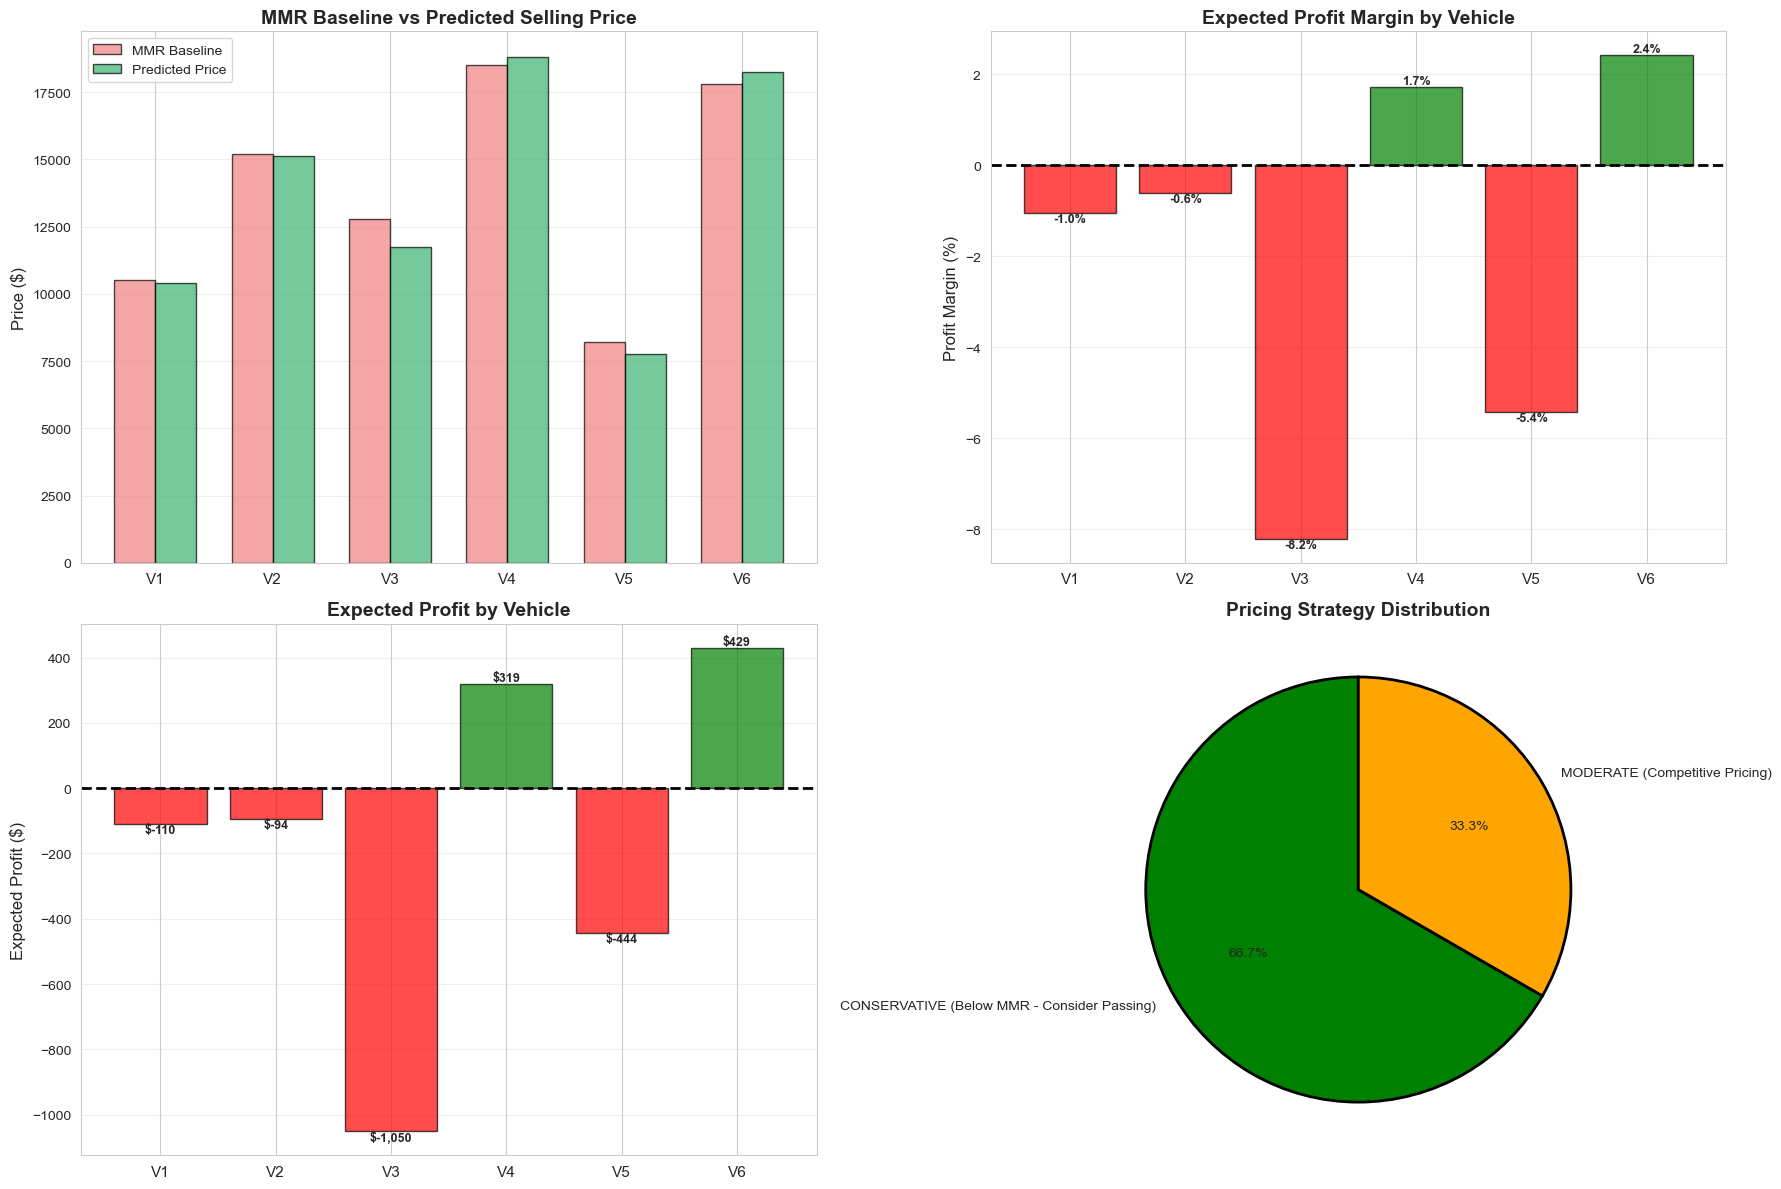


💡 Business Insight: ML-based pricing enables data-driven strategy selection!


In [35]:
# Create comprehensive pricing comparison table
pricing_df = pd.DataFrame(predictions_results)

print("="*120)
print("COMPREHENSIVE PRICING STRATEGY TABLE")
print("="*120)
print(pricing_df.to_string(index=False))
print("="*120)

# Summary statistics
print("\n📈 PORTFOLIO SUMMARY:")
print(f"   Total Vehicles Analyzed: {len(pricing_df)}")
print(f"   Total MMR Investment: ${pricing_df['MMR'].sum():,.2f}")
print(f"   Total Expected Revenue: ${pricing_df['Ensemble Price'].sum():,.2f}")
print(f"   Total Expected Profit: ${pricing_df['Expected Profit'].sum():,.2f}")
print(f"   Average Profit Margin: {pricing_df['Profit Margin %'].mean():.2f}%")
print(f"   Profitable Vehicles: {(pricing_df['Expected Profit'] > 0).sum()} / {len(pricing_df)}")

# Visualize pricing strategy
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Price comparison
x_pos = np.arange(len(pricing_df))
width = 0.35

axes[0, 0].bar(x_pos - width/2, pricing_df['MMR'], width, label='MMR Baseline', 
               color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 0].bar(x_pos + width/2, pricing_df['Ensemble Price'], width, label='Predicted Price',
               color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels([f"V{i+1}" for i in range(len(pricing_df))], fontsize=11)
axes[0, 0].set_ylabel('Price ($)', fontsize=12)
axes[0, 0].set_title('MMR Baseline vs Predicted Selling Price', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Profit margins
colors = ['green' if x > 0 else 'red' for x in pricing_df['Profit Margin %']]
axes[0, 1].bar(x_pos, pricing_df['Profit Margin %'], color=colors, edgecolor='black', alpha=0.7)
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels([f"V{i+1}" for i in range(len(pricing_df))], fontsize=11)
axes[0, 1].set_ylabel('Profit Margin (%)', fontsize=12)
axes[0, 1].set_title('Expected Profit Margin by Vehicle', fontsize=14, fontweight='bold')
for i, v in enumerate(pricing_df['Profit Margin %']):
    axes[0, 1].text(i, v, f'{v:.1f}%', ha='center', va='bottom' if v > 0 else 'top', fontweight='bold', fontsize=9)
axes[0, 1].grid(axis='y', alpha=0.3)

# Expected profit dollars
axes[1, 0].bar(x_pos, pricing_df['Expected Profit'], color=colors, edgecolor='black', alpha=0.7)
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=2)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([f"V{i+1}" for i in range(len(pricing_df))], fontsize=11)
axes[1, 0].set_ylabel('Expected Profit ($)', fontsize=12)
axes[1, 0].set_title('Expected Profit by Vehicle', fontsize=14, fontweight='bold')
for i, v in enumerate(pricing_df['Expected Profit']):
    axes[1, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom' if v > 0 else 'top', fontweight='bold', fontsize=9)
axes[1, 0].grid(axis='y', alpha=0.3)

# Strategy distribution
strategy_counts = pricing_df['Strategy'].value_counts()
colors_strategy = ['green', 'orange', 'red']
axes[1, 1].pie(strategy_counts.values, labels=strategy_counts.index, autopct='%1.1f%%',
               colors=colors_strategy[:len(strategy_counts)], startangle=90, 
               wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1, 1].set_title('Pricing Strategy Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Business Insight: ML-based pricing enables data-driven strategy selection!")


### 10.4 Scenario Analysis: Dynamic Pricing Strategies

Let's demonstrate how pricing changes under different market conditions.


SCENARIO ANALYSIS: 2013 Toyota Sedan - How Features Impact Price

Base Case                           | Odo:  75,000 | Cond:   35 | Price: $12,235.37 | Profit: $ -264.63 (-2.12%)

Excellent Condition                 | Odo:  75,000 | Cond:   42 | Price: $12,573.23 | Profit: $   73.23 ( 0.59%)

Low Mileage                         | Odo:  35,000 | Cond:   35 | Price: $12,368.95 | Profit: $ -131.05 (-1.05%)

High Mileage                        | Odo: 125,000 | Cond:   35 | Price: $11,608.96 | Profit: $ -891.04 (-7.13%)

Poor Condition                      | Odo:  75,000 | Cond:   22 | Price: $11,528.76 | Profit: $ -971.24 (-7.77%)

Best Case (Low Miles + Excellent)   | Odo:  35,000 | Cond:   42 | Price: $12,767.20 | Profit: $  267.20 ( 2.14%)


Detailed Scenario Comparison:
                         Scenario  Odometer  Condition  Predicted Price      Profit  Margin %       vs Base
                        Base Case     75000         35     12235.370912 -264.629088 -2.117033  1.818989e-12
   

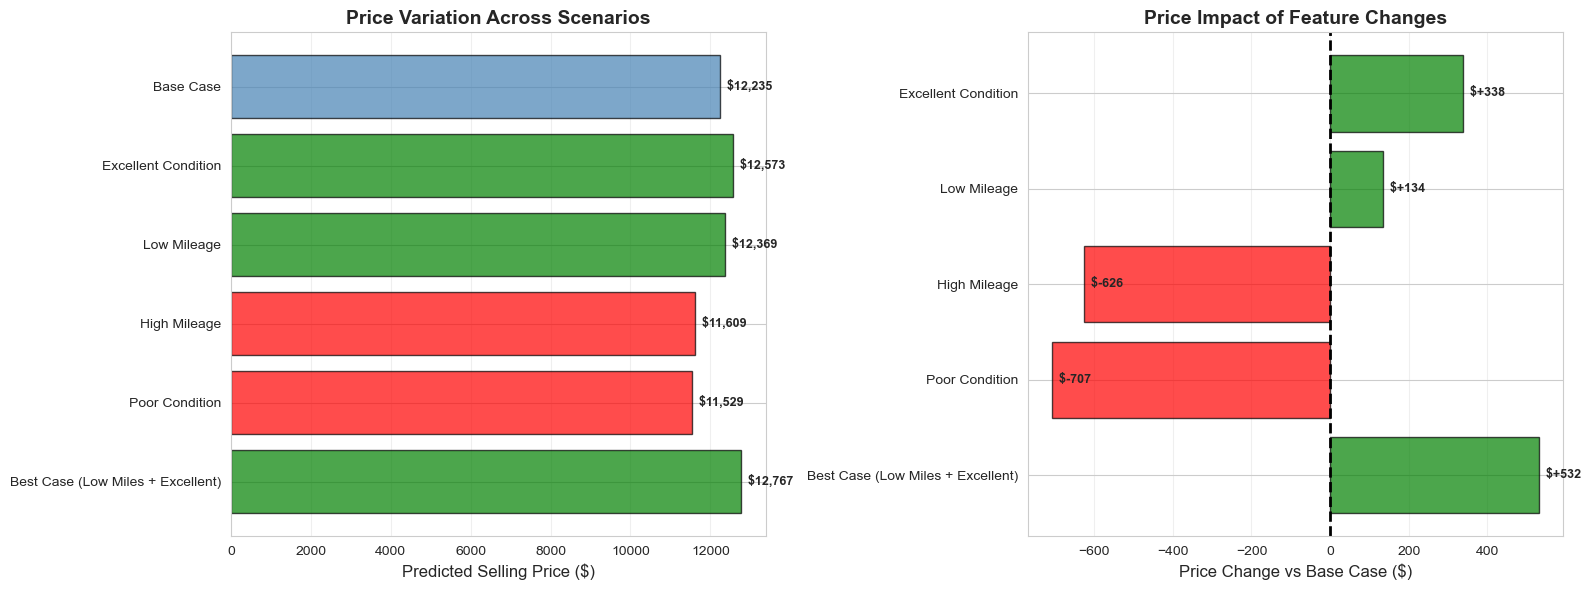


💡 Key Finding: Condition and mileage have significant impact on achievable price!


In [36]:
# Scenario analysis - Same vehicle under different conditions
base_vehicle = {
    'year': 2013,
    'make': 'Toyota',
    'body': 'Sedan',
    'transmission': 'automatic',
    'odometer': 75000,
    'condition': 35,
    'mmr': 12500
}

scenarios = [
    {'name': 'Base Case', 'changes': {}},
    {'name': 'Excellent Condition', 'changes': {'condition': 42}},
    {'name': 'Low Mileage', 'changes': {'odometer': 35000}},
    {'name': 'High Mileage', 'changes': {'odometer': 125000}},
    {'name': 'Poor Condition', 'changes': {'condition': 22}},
    {'name': 'Best Case (Low Miles + Excellent)', 'changes': {'odometer': 35000, 'condition': 42}},
]

scenario_results = []

print("="*100)
print("SCENARIO ANALYSIS: 2013 Toyota Sedan - How Features Impact Price")
print("="*100)

for scenario in scenarios:
    vehicle = base_vehicle.copy()
    vehicle.update(scenario['changes'])
    
    result = predict_vehicle_price(**vehicle)
    ensemble_price = result['predictions']['Ensemble (Recommended)']
    profit = result['business_metrics']['predicted_profit_ensemble']
    margin = result['business_metrics']['profit_margin_ensemble']
    
    scenario_results.append({
        'Scenario': scenario['name'],
        'Odometer': vehicle['odometer'],
        'Condition': vehicle['condition'],
        'Predicted Price': ensemble_price,
        'Profit': profit,
        'Margin %': margin,
        'vs Base': ensemble_price - predict_vehicle_price(**base_vehicle)['predictions']['Ensemble (Recommended)']
    })
    
    print(f"\n{scenario['name']:35s} | Odo: {vehicle['odometer']:>7,} | Cond: {vehicle['condition']:>4.0f} | "
          f"Price: ${ensemble_price:>9,.2f} | Profit: ${profit:>8,.2f} ({margin:>5.2f}%)")

scenario_df = pd.DataFrame(scenario_results)
print("\n" + "="*100)
print("\nDetailed Scenario Comparison:")
print(scenario_df.to_string(index=False))
print("="*100)

# Visualize scenario impact
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price impact by scenario
colors_scenario = ['steelblue'] + ['green' if x > 0 else 'red' for x in scenario_df['vs Base'][1:]]
axes[0].barh(range(len(scenario_df)), scenario_df['Predicted Price'], color=colors_scenario, edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(scenario_df)))
axes[0].set_yticklabels(scenario_df['Scenario'])
axes[0].set_xlabel('Predicted Selling Price ($)', fontsize=12)
axes[0].set_title('Price Variation Across Scenarios', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(scenario_df['Predicted Price']):
    axes[0].text(v, i, f'  ${v:,.0f}', va='center', fontweight='bold', fontsize=9)

# Price change from base
price_changes = scenario_df['vs Base'][1:]  # Exclude base case
scenario_names = scenario_df['Scenario'][1:]
colors_change = ['green' if x > 0 else 'red' for x in price_changes]

axes[1].barh(range(len(price_changes)), price_changes, color=colors_change, edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(price_changes)))
axes[1].set_yticklabels(scenario_names)
axes[1].set_xlabel('Price Change vs Base Case ($)', fontsize=12)
axes[1].set_title('Price Impact of Feature Changes', fontsize=14, fontweight='bold')
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(price_changes):
    axes[1].text(v, i, f'  ${v:+,.0f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 Key Finding: Condition and mileage have significant impact on achievable price!")


In [38]:
import joblib
import pandas as pd
import os

# Create directories if they don't exist
os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)

# 1) Save models
joblib.dump(lr_model, "models/lr_model.pkl")
joblib.dump(rf_model, "models/rf_model.pkl")
joblib.dump(xgb_model, "models/xgb_model.pkl")

# 2) Save encoders & scaler
joblib.dump(label_encoders, "models/label_encoders.pkl")
joblib.dump(scaler, "models/scaler.pkl")

# 3) (Optional) Save a small BI summary so the app can load fast
#    These are small groupby tables you already computed.
bi_make = (df_clean.groupby('make')['sellingprice']
           .mean().sort_values(ascending=False).head(15).reset_index())
bi_condition = (df_clean.groupby('condition_category')['sellingprice']
                .mean().reset_index())
bi_margin = df_clean[['sellingprice','mmr']].copy()
bi_margin['profit_margin'] = (bi_margin['sellingprice'] - bi_margin['mmr'])/bi_margin['mmr']*100

bi_make.to_csv("data/bi_make.csv", index=False)
bi_condition.to_csv("data/bi_condition.csv", index=False)
bi_margin.sample(5000, random_state=74).to_csv("data/bi_margin_sample.csv", index=False)  # small sample
